<a href="https://colab.research.google.com/github/cicechencc/AIHC-5010/blob/main/Cice_implemented_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

#PATH OF FOLDER!!! MODIFY IF NEEDED:
DATA_DIR = Path("/content/drive/MyDrive/AIHC 5010/Project 2/ecgen-radiology")
#-----#

xml_paths = sorted(DATA_DIR.glob("*.xml"))

print("DATA_DIR =", DATA_DIR)
print("XML files found =", len(xml_paths))
print("Example file =", xml_paths[0].name)

Mounted at /content/drive
DATA_DIR = /content/drive/MyDrive/AIHC 5010/Project 2/ecgen-radiology
XML files found = 3955
Example file = 1.xml


In [4]:
n_xml_files = len(xml_paths)

print("DATA_DIR:", DATA_DIR)
print("n_xml_files:", n_xml_files)
print("First 5 files:", [p.name for p in xml_paths[:5]])

DATA_DIR: /content/drive/MyDrive/AIHC 5010/Project 2/ecgen-radiology
n_xml_files: 3955
First 5 files: ['1.xml', '10.xml', '100.xml', '1000.xml', '1001.xml']


In [5]:
from pathlib import Path
import pandas as pd
from xml.etree import ElementTree as ET
from tqdm.auto import tqdm

DATA_DIR = Path("/content/drive/MyDrive/AIHC 5010/Project 2/ecgen-radiology")
xml_paths = sorted(DATA_DIR.glob("*.xml"), key=lambda p: int(p.stem))

TARGET_LABELS = ["COMPARISON", "INDICATION", "FINDINGS", "IMPRESSION"]

def extract_node_text(node):
    return " ".join(t.strip() for t in node.itertext() if t and t.strip())

def parse_one_xml(xml_path: Path) -> dict:
    try:
        root = ET.parse(xml_path).getroot()

        uid_node = root.find(".//uId")
        report_id = uid_node.attrib.get("id", "") if uid_node is not None else ""

        sections = {f"{lab.lower()}_raw": "" for lab in TARGET_LABELS}
        buckets = {lab: [] for lab in TARGET_LABELS}

        for node in root.findall(".//AbstractText"):
            label = (node.attrib.get("Label") or "").strip().upper()
            if label in buckets:
                txt = extract_node_text(node)
                if txt:
                    buckets[label].append(txt)

        for lab in TARGET_LABELS:
            sections[f"{lab.lower()}_raw"] = "\n".join(buckets[lab]) if buckets[lab] else ""

        n_images = len(root.findall(".//parentImage"))

        return {
            "report_id": report_id,
            **sections,
            "n_images": n_images,
            "xml_filename": xml_path.name,
            "xml_stem_num": int(xml_path.stem),
            "parse_success": True,
            "parse_error": "",
        }

    except Exception as e:
        return {
            "report_id": "",
            "comparison_raw": "",
            "indication_raw": "",
            "findings_raw": "",
            "impression_raw": "",
            "n_images": 0,
            "xml_filename": xml_path.name,
            "xml_stem_num": int(xml_path.stem),
            "parse_success": False,
            "parse_error": str(e),
        }

rows = [parse_one_xml(p) for p in tqdm(xml_paths)]
df_raw = pd.DataFrame(rows)

print("Rows parsed:", df_raw.shape[0])
print("Successful parses:", df_raw["parse_success"].sum())
print("Failed parses:", (~df_raw["parse_success"]).sum())
print("Unique report_id among successful parses:", df_raw.loc[df_raw["parse_success"], "report_id"].nunique())

df_raw.head(10)

  0%|          | 0/3955 [00:00<?, ?it/s]

Rows parsed: 3955
Successful parses: 3955
Failed parses: 0
Unique report_id among successful parses: 3955


,report_id,comparison_raw,indication_raw,findings_raw,impression_raw,n_images,xml_filename,xml_stem_num,parse_success,parse_error
0,CXR1,None.,Positive TB test,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,2,1.xml,1,True,
1,CXR2,None.,Preop bariatric surgery.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,2,2.xml,2,True,
2,CXR3,,"rib pain after a XXXX, XXXX XXXX steps this XX...",,"No displaced rib fractures, pneumothorax, or p...",2,3.xml,3,True,
3,CXR4,None available,XXXX-year-old XXXX with XXXX.,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,2,4.xml,4,True,
4,CXR5,,Chest and nasal congestion.,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,2,5.xml,5,True,
5,CXR6,"XXXX, XXXX",Evaluate for infection,Heart size and mediastinal contour are within ...,No acute cardiopulmonary findings.,2,6.xml,6,True,
6,CXR7,"XXXX, XXXX",Preop lumbar surgery,The cardiac contours are normal. XXXX basilar ...,Basilar atelectasis. No confluent lobar consol...,2,7.xml,7,True,
7,CXR8,Two views of the chest dated XXXX.,XXXX-year-old with XXXX on XXXX. Dyspnea. Hist...,"The heart, pulmonary XXXX and mediastinum are ...",No acute cardiopulmonary disease.,2,8.xml,8,True,
8,CXR9,"CT XXXX image XXXX, CT abdomen which included ...",Chest pain today. History of stent placement 7...,The XXXX examination consists of frontal and l...,Increased size of density in the left cardioph...,2,9.xml,9,True,
9,CXR10,Chest radiographs XXXX.,"XXXX-year-old male, chest pain.",The cardiomediastinal silhouette is within nor...,No acute cardiopulmonary process.,2,10.xml,10,True,


In [6]:
import re

SECTION_PREFIX_RE = re.compile(r"^(COMPARISON|INDICATION|FINDINGS|IMPRESSION)\s*:\s*", re.IGNORECASE)
DEID_RE = re.compile(r"\bX{2,}\b")
NONE_ONLY_RE = re.compile(r"^none\.?$", re.IGNORECASE)

def clean_base_text(text: str) -> str:
    if text is None:
        text = ""
    text = str(text)

    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()

    text = DEID_RE.sub("DEID_TOKEN", text)
    text = SECTION_PREFIX_RE.sub("", text).strip()

    if NONE_ONLY_RE.fullmatch(text):
        return ""

    return text

df_clean = df_raw.copy()

base_cols = ["comparison", "indication", "findings", "impression"]

for col in base_cols:
    df_clean[f"{col}_clean_base"] = df_clean[f"{col}_raw"].apply(clean_base_text)

df_clean[
    [
        "report_id",
        "comparison_raw", "comparison_clean_base",
        "indication_raw", "indication_clean_base",
        "findings_raw", "findings_clean_base",
        "impression_raw", "impression_clean_base"
    ]
].head(10)

df_clean

,report_id,comparison_raw,indication_raw,findings_raw,impression_raw,n_images,xml_filename,xml_stem_num,parse_success,parse_error,comparison_clean_base,indication_clean_base,findings_clean_base,impression_clean_base
0,CXR1,None.,Positive TB test,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,2,1.xml,1,True,,,Positive TB test,The cardiac silhouette and mediastinum size ar...,Normal chest x-DEID_TOKEN.
1,CXR2,None.,Preop bariatric surgery.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,2,2.xml,2,True,,,Preop bariatric surgery.,Borderline cardiomegaly. Midline sternotomy DE...,No acute pulmonary findings.
2,CXR3,,"rib pain after a XXXX, XXXX XXXX steps this XX...",,"No displaced rib fractures, pneumothorax, or p...",2,3.xml,3,True,,,"rib pain after a DEID_TOKEN, DEID_TOKEN DEID_T...",,"No displaced rib fractures, pneumothorax, or p..."
3,CXR4,None available,XXXX-year-old XXXX with XXXX.,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,2,4.xml,4,True,,None available,DEID_TOKEN-year-old DEID_TOKEN with DEID_TOKEN.,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,CXR5,,Chest and nasal congestion.,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,2,5.xml,5,True,,,Chest and nasal congestion.,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3950,CXR3995,"XXXX, XXXX.","Nausea, vomiting x2 weeks. Dialysis patient.",The cardiomediastinal silhouette and pulmonary...,1. Interval resolution of bibasilar airspace d...,2,3995.xml,3995,True,,"DEID_TOKEN, DEID_TOKEN.","Nausea, vomiting x2 weeks. Dialysis patient.",The cardiomediastinal silhouette and pulmonary...,1. Interval resolution of bibasilar airspace d...
3951,CXR3996,None.,,The lungs are clear. Heart size is normal. No ...,Clear lungs. No acute cardiopulmonary abnormal...,2,3996.xml,3996,True,,,,The lungs are clear. Heart size is normal. No ...,Clear lungs. No acute cardiopulmonary abnormal...
3952,CXR3997,None available.,XXXX-year-old male with positive PPD.,"Heart size within normal limits. Small, nodula...","No acute findings, no evidence for active TB.",2,3997.xml,3997,True,,None available.,DEID_TOKEN-year-old male with positive PPD.,"Heart size within normal limits. Small, nodula...","No acute findings, no evidence for active TB."
3953,CXR3998,,tuberculosis positive PPD,,Heart size is normal and the lungs are clear.,2,3998.xml,3998,True,,,tuberculosis positive PPD,,Heart size is normal and the lungs are clear.


In [7]:
import re

SECTION_PREFIX_RE = re.compile(r"^(COMPARISON|INDICATION|FINDINGS|IMPRESSION)\s*:\s*", re.IGNORECASE)
DEID_RE = re.compile(r"X{2,}")
EMPTY_PLACEHOLDER_RE = re.compile(r"^(none|none\.|none available|none available\.)$", re.IGNORECASE)

def clean_base_text(text: str) -> str:
    if text is None:
        text = ""
    text = str(text)

    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()

    text = DEID_RE.sub("DEID_TOKEN", text)
    text = SECTION_PREFIX_RE.sub("", text).strip()

    if EMPTY_PLACEHOLDER_RE.fullmatch(text):
        return ""

    return text

df_clean = df_raw.copy()

base_cols = ["comparison", "indication", "findings", "impression"]

for col in base_cols:
    df_clean[f"{col}_clean_base"] = df_clean[f"{col}_raw"].apply(clean_base_text)


df_clean

,report_id,comparison_raw,indication_raw,findings_raw,impression_raw,n_images,xml_filename,xml_stem_num,parse_success,parse_error,comparison_clean_base,indication_clean_base,findings_clean_base,impression_clean_base
0,CXR1,None.,Positive TB test,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,2,1.xml,1,True,,,Positive TB test,The cardiac silhouette and mediastinum size ar...,Normal chest x-DEID_TOKEN.
1,CXR2,None.,Preop bariatric surgery.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,2,2.xml,2,True,,,Preop bariatric surgery.,Borderline cardiomegaly. Midline sternotomy DE...,No acute pulmonary findings.
2,CXR3,,"rib pain after a XXXX, XXXX XXXX steps this XX...",,"No displaced rib fractures, pneumothorax, or p...",2,3.xml,3,True,,,"rib pain after a DEID_TOKEN, DEID_TOKEN DEID_T...",,"No displaced rib fractures, pneumothorax, or p..."
3,CXR4,None available,XXXX-year-old XXXX with XXXX.,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,2,4.xml,4,True,,,DEID_TOKEN-year-old DEID_TOKEN with DEID_TOKEN.,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,CXR5,,Chest and nasal congestion.,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,2,5.xml,5,True,,,Chest and nasal congestion.,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3950,CXR3995,"XXXX, XXXX.","Nausea, vomiting x2 weeks. Dialysis patient.",The cardiomediastinal silhouette and pulmonary...,1. Interval resolution of bibasilar airspace d...,2,3995.xml,3995,True,,"DEID_TOKEN, DEID_TOKEN.","Nausea, vomiting x2 weeks. Dialysis patient.",The cardiomediastinal silhouette and pulmonary...,1. Interval resolution of bibasilar airspace d...
3951,CXR3996,None.,,The lungs are clear. Heart size is normal. No ...,Clear lungs. No acute cardiopulmonary abnormal...,2,3996.xml,3996,True,,,,The lungs are clear. Heart size is normal. No ...,Clear lungs. No acute cardiopulmonary abnormal...
3952,CXR3997,None available.,XXXX-year-old male with positive PPD.,"Heart size within normal limits. Small, nodula...","No acute findings, no evidence for active TB.",2,3997.xml,3997,True,,,DEID_TOKEN-year-old male with positive PPD.,"Heart size within normal limits. Small, nodula...","No acute findings, no evidence for active TB."
3953,CXR3998,,tuberculosis positive PPD,,Heart size is normal and the lungs are clear.,2,3998.xml,3998,True,,,tuberculosis positive PPD,,Heart size is normal and the lungs are clear.


In [8]:
successful = df_clean["parse_success"] == True

clean_cols = [f"{col}_clean_base" for col in base_cols]

xxxx_remaining = {}
none_remaining = {}
empty_counts = {}

for col in clean_cols:
    xxxx_remaining[col] = df_clean.loc[successful, col].str.contains(r"X{2,}", regex=True, na=False).sum()
    none_remaining[col] = df_clean.loc[successful, col].str.fullmatch(r"none\.?", case=False, na=False).sum()
    empty_counts[col] = (df_clean.loc[successful, col] == "").sum()

print("Successful parsed rows:", successful.sum())
print("\nRemaining raw XXXX-like strings in cleaned columns:")
print(xxxx_remaining)
print("\nRemaining literal None/None. strings in cleaned columns:")
print(none_remaining)
print("\nEmpty cleaned fields by section:")
print(empty_counts)

Successful parsed rows: 3955

Remaining raw XXXX-like strings in cleaned columns:
{'comparison_clean_base': np.int64(0), 'indication_clean_base': np.int64(0), 'findings_clean_base': np.int64(0), 'impression_clean_base': np.int64(0)}

Remaining literal None/None. strings in cleaned columns:
{'comparison_clean_base': np.int64(0), 'indication_clean_base': np.int64(0), 'findings_clean_base': np.int64(0), 'impression_clean_base': np.int64(0)}

Empty cleaned fields by section:
{'comparison_clean_base': np.int64(2260), 'indication_clean_base': np.int64(90), 'findings_clean_base': np.int64(530), 'impression_clean_base': np.int64(34)}


In [9]:
def join_nonempty_sections(*parts):
    parts = [p.strip() for p in parts if isinstance(p, str) and p.strip() != ""]
    return "\n".join(parts)

df_step4 = df_clean.copy()

df_step4["text_impression"] = df_step4["impression_clean_base"]
df_step4["text_findings"] = df_step4["findings_clean_base"]

df_step4["text_full_embed"] = df_step4.apply(
    lambda row: join_nonempty_sections(
        row["indication_clean_base"],
        row["findings_clean_base"],
        row["impression_clean_base"]
    ),
    axis=1
)

df_step4[
    [
        "report_id",
        "indication_clean_base",
        "findings_clean_base",
        "impression_clean_base",
        "text_impression",
        "text_findings",
        "text_full_embed"
    ]
].head(10)

,report_id,indication_clean_base,findings_clean_base,impression_clean_base,text_impression,text_findings,text_full_embed
0,CXR1,Positive TB test,The cardiac silhouette and mediastinum size ar...,Normal chest x-DEID_TOKEN.,Normal chest x-DEID_TOKEN.,The cardiac silhouette and mediastinum size ar...,Positive TB test\nThe cardiac silhouette and m...
1,CXR2,Preop bariatric surgery.,Borderline cardiomegaly. Midline sternotomy DE...,No acute pulmonary findings.,No acute pulmonary findings.,Borderline cardiomegaly. Midline sternotomy DE...,Preop bariatric surgery.\nBorderline cardiomeg...
2,CXR3,"rib pain after a DEID_TOKEN, DEID_TOKEN DEID_T...",,"No displaced rib fractures, pneumothorax, or p...","No displaced rib fractures, pneumothorax, or p...",,"rib pain after a DEID_TOKEN, DEID_TOKEN DEID_T..."
3,CXR4,DEID_TOKEN-year-old DEID_TOKEN with DEID_TOKEN.,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,1. Bullous emphysema and interstitial fibrosis...,There are diffuse bilateral interstitial and a...,DEID_TOKEN-year-old DEID_TOKEN with DEID_TOKEN...
4,CXR5,Chest and nasal congestion.,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,No acute cardiopulmonary abnormality.,The cardiomediastinal silhouette and pulmonary...,Chest and nasal congestion.\nThe cardiomediast...
5,CXR6,Evaluate for infection,Heart size and mediastinal contour are within ...,No acute cardiopulmonary findings.,No acute cardiopulmonary findings.,Heart size and mediastinal contour are within ...,Evaluate for infection\nHeart size and mediast...
6,CXR7,Preop lumbar surgery,The cardiac contours are normal. DEID_TOKEN ba...,Basilar atelectasis. No confluent lobar consol...,Basilar atelectasis. No confluent lobar consol...,The cardiac contours are normal. DEID_TOKEN ba...,Preop lumbar surgery\nThe cardiac contours are...
7,CXR8,DEID_TOKEN-year-old with DEID_TOKEN on DEID_TO...,"The heart, pulmonary DEID_TOKEN and mediastinu...",No acute cardiopulmonary disease.,No acute cardiopulmonary disease.,"The heart, pulmonary DEID_TOKEN and mediastinu...",DEID_TOKEN-year-old with DEID_TOKEN on DEID_TO...
8,CXR9,Chest pain today. History of stent placement 7...,The DEID_TOKEN examination consists of frontal...,Increased size of density in the left cardioph...,Increased size of density in the left cardioph...,The DEID_TOKEN examination consists of frontal...,Chest pain today. History of stent placement 7...
9,CXR10,"DEID_TOKEN-year-old male, chest pain.",The cardiomediastinal silhouette is within nor...,No acute cardiopulmonary process.,No acute cardiopulmonary process.,The cardiomediastinal silhouette is within nor...,"DEID_TOKEN-year-old male, chest pain.\nThe car..."


In [10]:
step4_qc = {
    "empty_text_impression": (df_step4["text_impression"] == "").sum(),
    "empty_text_findings": (df_step4["text_findings"] == "").sum(),
    "empty_text_full_embed": (df_step4["text_full_embed"] == "").sum(),
    "double_blank_lines_in_full_embed": df_step4["text_full_embed"].str.contains(r"\n\s*\n", regex=True, na=False).sum(),
}

print(step4_qc)

{'empty_text_impression': np.int64(34), 'empty_text_findings': np.int64(530), 'empty_text_full_embed': np.int64(28), 'double_blank_lines_in_full_embed': np.int64(0)}


In [11]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

keep_words = {"no", "not", "without"}

stop_words = set(ENGLISH_STOP_WORDS) - keep_words

boilerplate_words = {
    "deid_token",
    "chest", "radiograph", "radiographs", "xray", "exam", "examination",
    "frontal", "lateral", "portable", "view", "views", "pa", "ap",
    "comparison", "dated",
    "year", "old", "male", "female"
}

all_remove_words = stop_words | boilerplate_words

def clean_for_lda(text):
    if text is None:
        return ""
    text = str(text).strip()
    if text == "":
        return ""

    text = text.lower()
    text = re.sub(r"\b\d+\.", " ", text)
    text = re.sub(r"\b\w*\d\w*\b", " ", text)
    text = text.replace("deid_token", " ")
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in all_remove_words and len(tok) > 1]

    return " ".join(tokens)

In [12]:
df_step5 = df_step4.copy()

df_step5["text_impression_lda"] = df_step5["text_impression"].apply(clean_for_lda)
df_step5["text_findings_lda"] = df_step5["text_findings"].apply(clean_for_lda)
df_step5["text_full_lda"] = df_step5["text_full_embed"].apply(clean_for_lda)

df_step5[
    [
        "report_id",
        "text_impression",
        "text_impression_lda",
        "text_findings",
        "text_findings_lda",
        "text_full_embed",
        "text_full_lda"
    ]
].head(10)

,report_id,text_impression,text_impression_lda,text_findings,text_findings_lda,text_full_embed,text_full_lda
0,CXR1,Normal chest x-DEID_TOKEN.,normal,The cardiac silhouette and mediastinum size ar...,cardiac silhouette mediastinum size normal lim...,Positive TB test\nThe cardiac silhouette and m...,positive tb test cardiac silhouette mediastinu...
1,CXR2,No acute pulmonary findings.,no acute pulmonary findings,Borderline cardiomegaly. Midline sternotomy DE...,borderline cardiomegaly midline sternotomy enl...,Preop bariatric surgery.\nBorderline cardiomeg...,preop bariatric surgery borderline cardiomegal...
2,CXR3,"No displaced rib fractures, pneumothorax, or p...",no displaced rib fractures pneumothorax pleura...,,,"rib pain after a DEID_TOKEN, DEID_TOKEN DEID_T...",rib pain steps pain elbow rib no previous hear...
3,CXR4,1. Bullous emphysema and interstitial fibrosis...,bullous emphysema interstitial fibrosis probab...,There are diffuse bilateral interstitial and a...,diffuse bilateral interstitial alveolar opacit...,DEID_TOKEN-year-old DEID_TOKEN with DEID_TOKEN...,diffuse bilateral interstitial alveolar opacit...
4,CXR5,No acute cardiopulmonary abnormality.,no acute cardiopulmonary abnormality,The cardiomediastinal silhouette and pulmonary...,cardiomediastinal silhouette pulmonary vascula...,Chest and nasal congestion.\nThe cardiomediast...,nasal congestion cardiomediastinal silhouette ...
5,CXR6,No acute cardiopulmonary findings.,no acute cardiopulmonary findings,Heart size and mediastinal contour are within ...,heart size mediastinal contour normal limits n...,Evaluate for infection\nHeart size and mediast...,evaluate infection heart size mediastinal cont...
6,CXR7,Basilar atelectasis. No confluent lobar consol...,basilar atelectasis no confluent lobar consoli...,The cardiac contours are normal. DEID_TOKEN ba...,cardiac contours normal basilar atelectasis lu...,Preop lumbar surgery\nThe cardiac contours are...,preop lumbar surgery cardiac contours normal b...
7,CXR8,No acute cardiopulmonary disease.,no acute cardiopulmonary disease,"The heart, pulmonary DEID_TOKEN and mediastinu...",heart pulmonary mediastinum normal limits no p...,DEID_TOKEN-year-old with DEID_TOKEN on DEID_TO...,dyspnea history mitral valve prolapse heart pu...
8,CXR9,Increased size of density in the left cardioph...,increased size density left cardiophrenic prim...,The DEID_TOKEN examination consists of frontal...,consists cardiac silhouette not enlarged appar...,Chest pain today. History of stent placement 7...,pain today history stent placement years ago c...
9,CXR10,No acute cardiopulmonary process.,no acute cardiopulmonary process,The cardiomediastinal silhouette is within nor...,cardiomediastinal silhouette normal limits siz...,"DEID_TOKEN-year-old male, chest pain.\nThe car...",pain cardiomediastinal silhouette normal limit...


In [13]:
step5_qc = {
    "empty_text_impression_lda": (df_step5["text_impression_lda"] == "").sum(),
    "empty_text_findings_lda": (df_step5["text_findings_lda"] == "").sum(),
    "empty_text_full_lda": (df_step5["text_full_lda"] == "").sum(),
    "deid_token_remaining_full_lda": df_step5["text_full_lda"].str.contains("deid_token", case=False, na=False).sum(),
    "digit_token_remaining_full_lda": df_step5["text_full_lda"].str.contains(r"\b\w*\d\w*\b", regex=True, na=False).sum(),
    "year_remaining_full_lda": df_step5["text_full_lda"].str.contains(r"\byear\b", regex=True, na=False).sum(),
    "old_remaining_full_lda": df_step5["text_full_lda"].str.contains(r"\bold\b", regex=True, na=False).sum(),
    "male_remaining_full_lda": df_step5["text_full_lda"].str.contains(r"\bmale\b", regex=True, na=False).sum(),
    "female_remaining_full_lda": df_step5["text_full_lda"].str.contains(r"\bfemale\b", regex=True, na=False).sum()
}

print(step5_qc)

{'empty_text_impression_lda': np.int64(34), 'empty_text_findings_lda': np.int64(532), 'empty_text_full_lda': np.int64(28), 'deid_token_remaining_full_lda': np.int64(0), 'digit_token_remaining_full_lda': np.int64(0), 'year_remaining_full_lda': np.int64(0), 'old_remaining_full_lda': np.int64(0), 'male_remaining_full_lda': np.int64(0), 'female_remaining_full_lda': np.int64(0)}


In [14]:
def word_count(text):
    if text is None:
        return 0
    text = str(text).strip()
    if text == "":
        return 0
    return len(text.split())

df_step6 = df_step5.copy()

text_cols = [
    "indication_clean_base",
    "text_impression",
    "text_findings",
    "text_full_embed",
    "text_impression_lda",
    "text_findings_lda",
    "text_full_lda"
]

for col in text_cols:
    df_step6[f"wc_{col}"] = df_step6[col].apply(word_count)
df_step6[
    [
        "report_id",
        "wc_indication_clean_base",
        "wc_text_impression",
        "wc_text_findings",
        "wc_text_full_embed",
        "wc_text_impression_lda",
        "wc_text_findings_lda",
        "wc_text_full_lda"
    ]
].head(10)

df_step6

,report_id,comparison_raw,indication_raw,findings_raw,impression_raw,n_images,xml_filename,xml_stem_num,parse_success,parse_error,...,text_impression_lda,text_findings_lda,text_full_lda,wc_indication_clean_base,wc_text_impression,wc_text_findings,wc_text_full_embed,wc_text_impression_lda,wc_text_findings_lda,wc_text_full_lda
0,CXR1,None.,Positive TB test,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,2,1.xml,1,True,,...,normal,cardiac silhouette mediastinum size normal lim...,positive tb test cardiac silhouette mediastinu...,3,3,34,40,1,18,22
1,CXR2,None.,Preop bariatric surgery.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,2,2.xml,2,True,,...,no acute pulmonary findings,borderline cardiomegaly midline sternotomy enl...,preop bariatric surgery borderline cardiomegal...,3,4,14,21,4,10,17
2,CXR3,,"rib pain after a XXXX, XXXX XXXX steps this XX...",,"No displaced rib fractures, pneumothorax, or p...",2,3.xml,3,True,,...,no displaced rib fractures pneumothorax pleura...,,rib pain steps pain elbow rib no previous hear...,30,23,0,53,20,0,35
3,CXR4,None available,XXXX-year-old XXXX with XXXX.,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,2,4.xml,4,True,,...,bullous emphysema interstitial fibrosis probab...,diffuse bilateral interstitial alveolar opacit...,diffuse bilateral interstitial alveolar opacit...,4,47,64,115,27,39,66
4,CXR5,,Chest and nasal congestion.,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,2,5.xml,5,True,,...,no acute cardiopulmonary abnormality,cardiomediastinal silhouette pulmonary vascula...,nasal congestion cardiomediastinal silhouette ...,4,4,42,50,4,28,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3950,CXR3995,"XXXX, XXXX.","Nausea, vomiting x2 weeks. Dialysis patient.",The cardiomediastinal silhouette and pulmonary...,1. Interval resolution of bibasilar airspace d...,2,3995.xml,3995,True,,...,interval resolution bibasilar airspace disease...,cardiomediastinal silhouette pulmonary vascula...,nausea vomiting weeks dialysis patient cardiom...,6,15,74,95,9,41,55
3951,CXR3996,None.,,The lungs are clear. Heart size is normal. No ...,Clear lungs. No acute cardiopulmonary abnormal...,2,3996.xml,3996,True,,...,clear lungs no acute cardiopulmonary abnormality,lungs clear heart size normal no pneumothorax ...,lungs clear heart size normal no pneumothorax ...,0,7,17,24,6,10,16
3952,CXR3997,None available.,XXXX-year-old male with positive PPD.,"Heart size within normal limits. Small, nodula...","No acute findings, no evidence for active TB.",2,3997.xml,3997,True,,...,no acute findings no evidence active tb,heart size normal limits small nodular opacity...,positive ppd heart size normal limits small no...,5,8,31,44,7,21,30
3953,CXR3998,,tuberculosis positive PPD,,Heart size is normal and the lungs are clear.,2,3998.xml,3998,True,,...,heart size normal lungs clear,,tuberculosis positive ppd heart size normal lu...,3,9,0,12,5,0,8


In [15]:
df_step6["missing_indication"] = df_step6["indication_clean_base"] == ""
df_step6["missing_impression"] = df_step6["text_impression"] == ""
df_step6["missing_findings"] = df_step6["text_findings"] == ""
df_step6["missing_full_embed"] = df_step6["text_full_embed"] == ""

df_step6["missing_impression_lda"] = df_step6["text_impression_lda"] == ""
df_step6["missing_findings_lda"] = df_step6["text_findings_lda"] == ""
df_step6["missing_full_lda"] = df_step6["text_full_lda"] == ""

df_step6[
    [
        "report_id",
        "missing_indication",
        "missing_impression",
        "missing_findings",
        "missing_full_embed",
        "missing_impression_lda",
        "missing_findings_lda",
        "missing_full_lda"
    ]
].head(10)

df_step6

,report_id,comparison_raw,indication_raw,findings_raw,impression_raw,n_images,xml_filename,xml_stem_num,parse_success,parse_error,...,wc_text_impression_lda,wc_text_findings_lda,wc_text_full_lda,missing_indication,missing_impression,missing_findings,missing_full_embed,missing_impression_lda,missing_findings_lda,missing_full_lda
0,CXR1,None.,Positive TB test,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,2,1.xml,1,True,,...,1,18,22,False,False,False,False,False,False,False
1,CXR2,None.,Preop bariatric surgery.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,2,2.xml,2,True,,...,4,10,17,False,False,False,False,False,False,False
2,CXR3,,"rib pain after a XXXX, XXXX XXXX steps this XX...",,"No displaced rib fractures, pneumothorax, or p...",2,3.xml,3,True,,...,20,0,35,False,False,True,False,False,True,False
3,CXR4,None available,XXXX-year-old XXXX with XXXX.,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,2,4.xml,4,True,,...,27,39,66,False,False,False,False,False,False,False
4,CXR5,,Chest and nasal congestion.,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,2,5.xml,5,True,,...,4,28,34,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3950,CXR3995,"XXXX, XXXX.","Nausea, vomiting x2 weeks. Dialysis patient.",The cardiomediastinal silhouette and pulmonary...,1. Interval resolution of bibasilar airspace d...,2,3995.xml,3995,True,,...,9,41,55,False,False,False,False,False,False,False
3951,CXR3996,None.,,The lungs are clear. Heart size is normal. No ...,Clear lungs. No acute cardiopulmonary abnormal...,2,3996.xml,3996,True,,...,6,10,16,True,False,False,False,False,False,False
3952,CXR3997,None available.,XXXX-year-old male with positive PPD.,"Heart size within normal limits. Small, nodula...","No acute findings, no evidence for active TB.",2,3997.xml,3997,True,,...,7,21,30,False,False,False,False,False,False,False
3953,CXR3998,,tuberculosis positive PPD,,Heart size is normal and the lungs are clear.,2,3998.xml,3998,True,,...,5,0,8,False,False,True,False,False,True,False


In [17]:
qc_summary_step6 = {
    "n_reports": len(df_step6),

    "empty_text_impression": df_step6["missing_impression"].sum(),
    "empty_text_findings": df_step6["missing_findings"].sum(),
    "empty_text_full_embed": df_step6["missing_full_embed"].sum(),

    "empty_text_impression_lda": df_step6["missing_impression_lda"].sum(),
    "empty_text_findings_lda": df_step6["missing_findings_lda"].sum(),
    "empty_text_full_lda": df_step6["missing_full_lda"].sum(),

    "median_wc_text_impression": df_step6["wc_text_impression"].median(),
    "median_wc_text_findings": df_step6["wc_text_findings"].median(),
    "median_wc_text_full_embed": df_step6["wc_text_full_embed"].median(),

    "median_wc_text_impression_lda": df_step6["wc_text_impression_lda"].median(),
    "median_wc_text_findings_lda": df_step6["wc_text_findings_lda"].median(),
    "median_wc_text_full_lda": df_step6["wc_text_full_lda"].median(),
}

print(qc_summary_step6)

{'n_reports': 3955, 'empty_text_impression': np.int64(34), 'empty_text_findings': np.int64(530), 'empty_text_full_embed': np.int64(28), 'empty_text_impression_lda': np.int64(34), 'empty_text_findings_lda': np.int64(532), 'empty_text_full_lda': np.int64(28), 'median_wc_text_impression': 5.0, 'median_wc_text_findings': 27.0, 'median_wc_text_full_embed': 38.0, 'median_wc_text_impression_lda': 4.0, 'median_wc_text_findings_lda': 18.0, 'median_wc_text_full_lda': 26.0}


In [18]:
df_step6.loc[df_step6["wc_text_full_lda"] > 0, ["report_id", "text_full_lda", "wc_text_full_lda"]] \
    .sort_values("wc_text_full_lda") \
    .head(15)

,report_id,text_full_lda,wc_text_full_lda
2574,CXR2604,pain no active disease,4
2989,CXR3026,sob no active disease,4
2579,CXR2609,pain no active disease,4
3849,CXR3894,tb no active disease,4
3186,CXR3225,pain no active disease,4
3675,CXR3719,dyspnea no active disease,4
1954,CXR1975,pain no active disease,4
2408,CXR2435,pain no active disease,4
1026,CXR1038,heart size normal lungs clear,5
3316,CXR3358,ppd reactive no active disease,5


In [19]:
# Master processed dataset remains unchanged
df_master = df_step6.copy()

# Full-text BERTopic / embedding-ready dataset
df_full_embed_model = df_master[
    (~df_master["missing_full_embed"]) &
    (df_master["wc_text_full_embed"] >= 15)
].copy()

# Full-text LDA-ready dataset, threshold = 15 words
df_full_lda_model = df_master[
    (~df_master["missing_full_lda"]) &
    (df_master["wc_text_full_lda"] >= 15)
].copy()

# Optional stricter LDA sensitivity dataset, threshold = 20 words
df_full_lda_model_20 = df_master[
    (~df_master["missing_full_lda"]) &
    (df_master["wc_text_full_lda"] >= 20)
].copy()

print("Master dataset rows:", len(df_master))
print("BERTopic full-text model rows:", len(df_full_embed_model))
print("LDA full-text model rows (>=15 words):", len(df_full_lda_model))
print("LDA full-text model rows (>=20 words):", len(df_full_lda_model_20))

Master dataset rows: 3955
BERTopic full-text model rows: 3832
LDA full-text model rows (>=15 words): 3525
LDA full-text model rows (>=20 words): 2983


In [22]:
df_master["eligible_impression_embed"] = ~df_master["missing_impression"]
df_master["eligible_findings_embed"] = ~df_master["missing_findings"]

df_master["eligible_impression_lda"] = ~df_master["missing_impression_lda"]
df_master["eligible_findings_lda"] = ~df_master["missing_findings_lda"]

# Optional "very short" flags for later review, not hard filtering
df_master["very_short_impression_lda"] = (
    df_master["eligible_impression_lda"] &
    (df_master["wc_text_impression_lda"] < 4)
)

df_master["very_short_findings_lda"] = (
    df_master["eligible_findings_lda"] &
    (df_master["wc_text_findings_lda"] < 8)
)

section_flag_summary = {
    "eligible_impression_embed": int(df_master["eligible_impression_embed"].sum()),
    "eligible_findings_embed": int(df_master["eligible_findings_embed"].sum()),
    "eligible_impression_lda": int(df_master["eligible_impression_lda"].sum()),
    "eligible_findings_lda": int(df_master["eligible_findings_lda"].sum()),
    "very_short_impression_lda": int(df_master["very_short_impression_lda"].sum()),
    "very_short_findings_lda": int(df_master["very_short_findings_lda"].sum()),
}

print(section_flag_summary)

{'eligible_impression_embed': 3921, 'eligible_findings_embed': 3425, 'eligible_impression_lda': 3921, 'eligible_findings_lda': 3423, 'very_short_impression_lda': 614, 'very_short_findings_lda': 126}


In [23]:
duplicate_summary = {
    "master_full_embed_exact_duplicates": int(df_master.duplicated(subset=["text_full_embed"]).sum()),
    "master_full_lda_exact_duplicates": int(df_master.duplicated(subset=["text_full_lda"]).sum()),
    "filtered_full_embed_exact_duplicates": int(df_full_embed_model.duplicated(subset=["text_full_embed"]).sum()),
    "filtered_full_lda_exact_duplicates": int(df_full_lda_model.duplicated(subset=["text_full_lda"]).sum()),
    "filtered_full_lda_20_exact_duplicates": int(df_full_lda_model_20.duplicated(subset=["text_full_lda"]).sum()),
}

print(duplicate_summary)

{'master_full_embed_exact_duplicates': 174, 'master_full_lda_exact_duplicates': 297, 'filtered_full_embed_exact_duplicates': 136, 'filtered_full_lda_exact_duplicates': 166, 'filtered_full_lda_20_exact_duplicates': 105}


In [24]:
retention_counts = {
    "n_xml_files": n_xml_files,
    "n_parsed": int(df_raw["parse_success"].sum()),
    "n_master_processed": len(df_master),

    "n_kept_full_embed": len(df_full_embed_model),
    "n_kept_full_lda_15": len(df_full_lda_model),
    "n_kept_full_lda_20": len(df_full_lda_model_20),

    "n_eligible_impression_embed": int(df_master["eligible_impression_embed"].sum()),
    "n_eligible_findings_embed": int(df_master["eligible_findings_embed"].sum()),
    "n_eligible_impression_lda": int(df_master["eligible_impression_lda"].sum()),
    "n_eligible_findings_lda": int(df_master["eligible_findings_lda"].sum()),
}

print(retention_counts)

{'n_xml_files': 3955, 'n_parsed': 3955, 'n_master_processed': 3955, 'n_kept_full_embed': 3832, 'n_kept_full_lda_15': 3525, 'n_kept_full_lda_20': 2983, 'n_eligible_impression_embed': 3921, 'n_eligible_findings_embed': 3425, 'n_eligible_impression_lda': 3921, 'n_eligible_findings_lda': 3423}


In [25]:
print("Shortest retained LDA full-text documents (>=15 words):")
display(
    df_full_lda_model[["report_id", "text_full_lda", "wc_text_full_lda"]]
    .sort_values("wc_text_full_lda")
    .head(10)
)



Shortest retained LDA full-text documents (>=15 words):


,report_id,text_full_lda,wc_text_full_lda
750,CXR759,lungs clear cardiomediastinal silhouette norma...,15
3774,CXR3818,pain heart mediastinum normal limits negative ...,15
2706,CXR2739,heart size normal limits no focal airspace dis...,15
2419,CXR2446,pain heart lungs interval lungs clear expanded...,15
2436,CXR2463,dyspnea heart size normal lungs relatively cle...,15
2455,CXR2482,history tube removal stable cm right apical pn...,15
2448,CXR2475,pain heart size remains slightly large pulmona...,15
2641,CXR2672,pain heart mediastinum unremarkable lungs clea...,15
3691,CXR3735,followup lung nodule cardiac contours normal a...,15
3653,CXR3696,preop surgery surgery jaw heart size normal lu...,15


In [26]:
print("Shortest excluded LDA full-text documents (<15 words but non-empty):")
display(
    df_master[
        (~df_master["missing_full_lda"]) &
        (df_master["wc_text_full_lda"] < 15)
    ][["report_id", "text_full_lda", "wc_text_full_lda"]]
    .sort_values("wc_text_full_lda")
    .head(10)
)



Shortest excluded LDA full-text documents (<15 words but non-empty):


,report_id,text_full_lda,wc_text_full_lda
2989,CXR3026,sob no active disease,4
2574,CXR2604,pain no active disease,4
3186,CXR3225,pain no active disease,4
2579,CXR2609,pain no active disease,4
2408,CXR2435,pain no active disease,4
3849,CXR3894,tb no active disease,4
3675,CXR3719,dyspnea no active disease,4
1954,CXR1975,pain no active disease,4
1026,CXR1038,heart size normal lungs clear,5
3411,CXR3453,heart size normal lungs clear,5


In [27]:
duplicate_summary = {
    "master_full_embed_exact_duplicates": int(df_master.duplicated(subset=["text_full_embed"]).sum()),
    "master_full_lda_exact_duplicates": int(df_master.duplicated(subset=["text_full_lda"]).sum()),
    "filtered_full_embed_exact_duplicates": int(df_full_embed_model.duplicated(subset=["text_full_embed"]).sum()),
    "filtered_full_lda_exact_duplicates": int(df_full_lda_model.duplicated(subset=["text_full_lda"]).sum()),
    "filtered_full_lda_20_exact_duplicates": int(df_full_lda_model_20.duplicated(subset=["text_full_lda"]).sum()),
}

print(duplicate_summary)

{'master_full_embed_exact_duplicates': 174, 'master_full_lda_exact_duplicates': 297, 'filtered_full_embed_exact_duplicates': 136, 'filtered_full_lda_exact_duplicates': 166, 'filtered_full_lda_20_exact_duplicates': 105}


In [28]:
import pandas as pd

def show_duplicate_groups(df, text_col, top_n=15):
    dup_counts = (
        df[df[text_col] != ""]
        .groupby(text_col)
        .size()
        .reset_index(name="n_reports")
        .query("n_reports > 1")
        .sort_values(["n_reports", text_col], ascending=[False, True])
    )

    print(f"Duplicate groups in {text_col}: {len(dup_counts)}")
    return dup_counts.head(top_n)

show_duplicate_groups(df_master, "text_full_lda", top_n=15)

Duplicate groups in text_full_lda: 111


,text_full_lda,n_reports
955,heart size normal lungs clear normal no pneumo...,14
2044,pain heart size normal lungs clear normal no p...,12
1929,pain heart lungs interval lungs clear expanded...,11
1955,pain heart normal size mediastinum unremarkabl...,11
897,heart normal size mediastinum unremarkable lun...,10
877,heart lungs interval lungs clear expanded hear...,8
2036,pain heart size normal lungs clear,8
2021,pain heart size normal limits no focal alveola...,7
2045,pain heart size normal mediastinal contour nor...,7
2130,pain lungs clear bilaterally cardiac mediastin...,7


In [29]:
def show_duplicate_examples(df, text_col, top_n=10, max_ids=10):
    dup_counts = (
        df[df[text_col] != ""]
        .groupby(text_col)
        .size()
        .reset_index(name="n_reports")
        .query("n_reports > 1")
        .sort_values(["n_reports", text_col], ascending=[False, True])
        .head(top_n)
    )

    rows = []
    for _, r in dup_counts.iterrows():
        txt = r[text_col]
        matched = df[df[text_col] == txt]["report_id"].tolist()
        rows.append({
            "n_reports": r["n_reports"],
            "report_ids": matched[:max_ids],
            text_col: txt
        })

    return pd.DataFrame(rows)

show_duplicate_examples(df_master, "text_full_lda", top_n=10, max_ids=12)

,n_reports,report_ids,text_full_lda
0,14,"[CXR162, CXR204, CXR1304, CXR1588, CXR1679, CX...",heart size normal lungs clear normal no pneumo...
1,12,"[CXR136, CXR265, CXR523, CXR1345, CXR1415, CXR...",pain heart size normal lungs clear normal no p...
2,11,"[CXR151, CXR198, CXR280, CXR613, CXR738, CXR11...",pain heart lungs interval lungs clear expanded...
3,11,"[CXR203, CXR366, CXR717, CXR855, CXR928, CXR19...",pain heart normal size mediastinum unremarkabl...
4,10,"[CXR1259, CXR1368, CXR1461, CXR1476, CXR1657, ...",heart normal size mediastinum unremarkable lun...
5,8,"[CXR1077, CXR1091, CXR1866, CXR2204, CXR2780, ...",heart lungs interval lungs clear expanded hear...
6,8,"[CXR433, CXR445, CXR719, CXR727, CXR766, CXR98...",pain heart size normal lungs clear
7,7,"[CXR18, CXR751, CXR968, CXR1477, CXR1482, CXR1...",pain heart size normal limits no focal alveola...
8,7,"[CXR444, CXR1377, CXR2910, CXR2915, CXR3496, C...",pain heart size normal mediastinal contour nor...
9,7,"[CXR324, CXR2083, CXR2453, CXR2561, CXR3063, C...",pain lungs clear bilaterally cardiac mediastin...


In [30]:
for col in ["text_full_embed", "text_full_lda", "text_impression_lda", "text_findings_lda"]:
    print(f"\n===== {col} =====")
    display(show_duplicate_examples(df_master, col, top_n=5, max_ids=10))


===== text_full_embed =====


,n_reports,report_ids,text_full_embed
0,9,"[CXR203, CXR366, CXR717, CXR1931, CXR1966, CXR...",Chest pain\nThe heart is normal in size. The m...
1,8,"[CXR136, CXR265, CXR523, CXR1345, CXR1415, CXR...",chest pain\nHeart size normal. Lungs are clear...
2,6,"[CXR588, CXR1489, CXR2480, CXR3329, CXR3438, C...",Chest pain.\nThe heart is normal in size and c...
3,6,"[CXR162, CXR204, CXR1679, CXR1779, CXR3157, CX...",DEID_TOKEN.\nHeart size normal. Lungs are clea...
4,6,"[CXR151, CXR280, CXR738, CXR1150, CXR1222, CXR...",chest pain\nThe heart and lungs have DEID_TOKE...



===== text_full_lda =====


,n_reports,report_ids,text_full_lda
0,14,"[CXR162, CXR204, CXR1304, CXR1588, CXR1679, CX...",heart size normal lungs clear normal no pneumo...
1,12,"[CXR136, CXR265, CXR523, CXR1345, CXR1415, CXR...",pain heart size normal lungs clear normal no p...
2,11,"[CXR151, CXR198, CXR280, CXR613, CXR738, CXR11...",pain heart lungs interval lungs clear expanded...
3,11,"[CXR203, CXR366, CXR717, CXR855, CXR928, CXR19...",pain heart normal size mediastinum unremarkabl...
4,10,"[CXR1259, CXR1368, CXR1461, CXR1476, CXR1657, ...",heart normal size mediastinum unremarkable lun...



===== text_impression_lda =====


,n_reports,report_ids,text_impression_lda
0,415,"[CXR5, CXR12, CXR17, CXR22, CXR24, CXR36, CXR5...",no acute cardiopulmonary abnormality
1,185,"[CXR6, CXR11, CXR15, CXR18, CXR86, CXR164, CXR...",no acute cardiopulmonary findings
2,163,"[CXR8, CXR34, CXR44, CXR49, CXR69, CXR71, CXR9...",no acute cardiopulmonary disease
3,137,"[CXR42, CXR89, CXR94, CXR114, CXR141, CXR158, ...",no acute cardiopulmonary abnormalities
4,135,"[CXR39, CXR43, CXR100, CXR134, CXR151, CXR167,...",no active disease



===== text_findings_lda =====


,n_reports,report_ids,text_findings_lda
0,53,"[CXR39, CXR43, CXR151, CXR198, CXR280, CXR402,...",heart lungs interval lungs clear expanded hear...
1,52,"[CXR56, CXR133, CXR203, CXR366, CXR561, CXR717...",heart normal size mediastinum unremarkable lun...
2,48,"[CXR136, CXR162, CXR204, CXR265, CXR497, CXR52...",heart size normal lungs clear normal no pneumo...
3,46,"[CXR36, CXR107, CXR276, CXR291, CXR344, CXR565...",lungs clear bilaterally specifically no eviden...
4,35,"[CXR110, CXR138, CXR176, CXR219, CXR419, CXR50...",cardiac mediastinal contours normal limits lun...


In [31]:
# Copy one duplicated text from the previous output and paste it here
dup_text_to_inspect = "pain no active disease"

df_master.loc[df_master["text_full_lda"] == dup_text_to_inspect, [
    "report_id",
    "indication_clean_base",
    "findings_clean_base",
    "impression_clean_base",
    "text_full_embed",
    "text_full_lda"
]].sort_values("report_id")

,report_id,indication_clean_base,findings_clean_base,impression_clean_base,text_full_embed,text_full_lda
1954,CXR1975,pain,,No active disease.,pain\nNo active disease.,pain no active disease
2408,CXR2435,chest pain,,No active disease.,chest pain\nNo active disease.,pain no active disease
2574,CXR2604,chest pain,,No active disease.,chest pain\nNo active disease.,pain no active disease
2579,CXR2609,pain,,No active disease.,pain\nNo active disease.,pain no active disease
3186,CXR3225,chest pain,,No active disease.,chest pain\nNo active disease.,pain no active disease


In [40]:
from google.colab import drive
from pathlib import Path
import pandas as pd

drive.mount("/content/drive")

HANDOFF_DIR = Path("/content/drive/MyDrive/AIHC 5010/Project 2/Hand_off_Project_2_AIHC5010/Hand_off_Project_2_AIHC5010")

print("Files in folder:")
for p in sorted(HANDOFF_DIR.iterdir()):
    print(p.name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in folder:
Methodology_Project_2.docx
README_data_handoff.md
corpus_extracts_embed.csv
corpus_extracts_lda.csv
duplicate_summary_step7.csv
qc_summary_step6.csv
reports_full_embed_model.parquet
reports_full_embed_model_10.parquet
reports_full_lda_model_10.parquet
reports_full_lda_model_15.parquet
reports_full_lda_model_20.parquet
reports_master_processed.csv
reports_master_processed.parquet
retention_counts_step7.csv
section_eligibility_summary_step7.csv


In [41]:
embed_path = HANDOFF_DIR / "reports_full_embed_model.parquet"
lda15_path = HANDOFF_DIR / "reports_full_lda_model_15.parquet"
lda20_path = HANDOFF_DIR / "reports_full_lda_model_20.parquet"

df_full_embed_model = pd.read_parquet(embed_path)
df_full_lda_model = pd.read_parquet(lda15_path)
df_full_lda_model_20 = pd.read_parquet(lda20_path)

print("Embed model shape:", df_full_embed_model.shape)
print("LDA 15 shape:", df_full_lda_model.shape)
print("LDA 20 shape:", df_full_lda_model_20.shape)

Embed model shape: (3832, 40)
LDA 15 shape: (3525, 40)
LDA 20 shape: (2983, 40)


In [42]:
print("Unique report_id in df_master:", df_master["report_id"].nunique())
print("Rows in df_master:", len(df_master))

assert df_master["report_id"].is_unique, "report_id is not unique in df_master"

Unique report_id in df_master: 3955
Rows in df_master: 3955


In [43]:
eligibility_cols = [
    "eligible_impression_embed",
    "eligible_findings_embed",
    "eligible_impression_lda",
    "eligible_findings_lda",
    "very_short_impression_lda",
    "very_short_findings_lda"
]

eligibility_lookup = df_master[["report_id"] + eligibility_cols].copy()
eligibility_lookup.head()

,report_id,eligible_impression_embed,eligible_findings_embed,eligible_impression_lda,eligible_findings_lda,very_short_impression_lda,very_short_findings_lda
0,CXR1,True,True,True,True,True,False
1,CXR2,True,True,True,True,False,False
2,CXR3,True,False,True,False,False,False
3,CXR4,True,True,True,True,False,False
4,CXR5,True,True,True,True,False,False


In [44]:
def add_eligibility_columns(filtered_df, lookup_df, key="report_id"):
    original_n = len(filtered_df)

    # Drop existing versions first if they already exist, to avoid _x / _y columns
    cols_to_drop = [c for c in eligibility_cols if c in filtered_df.columns]
    filtered_df = filtered_df.drop(columns=cols_to_drop, errors="ignore")

    merged_df = filtered_df.merge(
        lookup_df,
        on=key,
        how="left",
        validate="many_to_one"
    )

    assert len(merged_df) == original_n, "Row count changed after merge"
    return merged_df

In [45]:
df_full_embed_model = add_eligibility_columns(df_full_embed_model, eligibility_lookup)
df_full_lda_model = add_eligibility_columns(df_full_lda_model, eligibility_lookup)
df_full_lda_model_20 = add_eligibility_columns(df_full_lda_model_20, eligibility_lookup)

In [46]:
# Full-text BERTopic / embedding-ready dataset, threshold = 10 words
df_full_embed_model_10 = df_master[
    (~df_master["missing_full_embed"]) &
    (df_master["wc_text_full_embed"] >= 10)
].copy()

# Full-text LDA-ready dataset, threshold = 10 words
df_full_lda_model_10 = df_master[
    (~df_master["missing_full_lda"]) &
    (df_master["wc_text_full_lda"] >= 10)
].copy()

print("BERTopic full-text model rows (>=10 words):", len(df_full_embed_model_10))
print("LDA full-text model rows (>=10 words):", len(df_full_lda_model_10))

# Add eligibility columns
df_full_embed_model_10 = add_eligibility_columns(df_full_embed_model_10, eligibility_lookup)
df_full_lda_model_10 = add_eligibility_columns(df_full_lda_model_10, eligibility_lookup)

# Export to parquet
df_full_embed_model_10.to_parquet(HANDOFF_DIR / "reports_full_embed_model_10.parquet", index=False)
df_full_lda_model_10.to_parquet(HANDOFF_DIR / "reports_full_lda_model_10.parquet", index=False)

print("Exported reports_full_embed_model_10.parquet")
print("Exported reports_full_lda_model_10.parquet")

BERTopic full-text model rows (>=10 words): 3900
LDA full-text model rows (>=10 words): 3859
Exported reports_full_embed_model_10.parquet
Exported reports_full_lda_model_10.parquet


In [47]:
# Summary table: retention and exclusion by word-count threshold
total = len(df_master)

summary_rows = [
    {
        "Dataset":        "BERTopic full-text",
        "Threshold":      "≥10 words",
        "N retained":     len(df_full_embed_model_10),
        "% retained":     round(100 * len(df_full_embed_model_10) / total, 1),
        "N excluded":     total - len(df_full_embed_model_10),
        "% excluded":     round(100 * (total - len(df_full_embed_model_10)) / total, 1),
    },
    {
        "Dataset":        "BERTopic full-text",
        "Threshold":      "≥15 words",
        "N retained":     len(df_full_embed_model),
        "% retained":     round(100 * len(df_full_embed_model) / total, 1),
        "N excluded":     total - len(df_full_embed_model),
        "% excluded":     round(100 * (total - len(df_full_embed_model)) / total, 1),
    },
    {
        "Dataset":        "LDA full-text",
        "Threshold":      "≥10 words",
        "N retained":     len(df_full_lda_model_10),
        "% retained":     round(100 * len(df_full_lda_model_10) / total, 1),
        "N excluded":     total - len(df_full_lda_model_10),
        "% excluded":     round(100 * (total - len(df_full_lda_model_10)) / total, 1),
    },
    {
        "Dataset":        "LDA full-text",
        "Threshold":      "≥15 words",
        "N retained":     len(df_full_lda_model),
        "% retained":     round(100 * len(df_full_lda_model) / total, 1),
        "N excluded":     total - len(df_full_lda_model),
        "% excluded":     round(100 * (total - len(df_full_lda_model)) / total, 1),
    },
    {
        "Dataset":        "LDA full-text",
        "Threshold":      "≥20 words",
        "N retained":     len(df_full_lda_model_20),
        "% retained":     round(100 * len(df_full_lda_model_20) / total, 1),
        "N excluded":     total - len(df_full_lda_model_20),
        "% excluded":     round(100 * (total - len(df_full_lda_model_20)) / total, 1),
    },
]

df_threshold_summary = pd.DataFrame(summary_rows)
print(f"Total reports in master: {total}\n")
display(df_threshold_summary)

Total reports in master: 3955



,Dataset,Threshold,N retained,% retained,N excluded,% excluded
0,BERTopic full-text,≥10 words,3900,98.6,55,1.4
1,BERTopic full-text,≥15 words,3832,96.9,123,3.1
2,LDA full-text,≥10 words,3859,97.6,96,2.4
3,LDA full-text,≥15 words,3525,89.1,430,10.9
4,LDA full-text,≥20 words,2983,75.4,972,24.6


# **Cice Implemented**

1. Run a fully unsupervised embedding-based clustering pipeline on radiology reports and perform a section ablation by comparing three text variants (Impression-only, Findings-only, and Full report).

In [48]:
!pip -q install bertopic sentence-transformers umap-learn hdbscan scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.0 MB/s eta 0:00:00


In [49]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import silhouette_score

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [51]:
# make sure all columns exist
required_cols = [
    "report_id",
    "text_impression",
    "text_findings",
    "text_full_embed"
]

missing = [c for c in required_cols if c not in df_master.columns]
if missing:
    raise ValueError(f"Missing required columns in df_master: {missing}")

print("All required columns found.")
print(df_master[required_cols].head())

All required columns found.
  report_id                                    text_impression  \
0      CXR1                         Normal chest x-DEID_TOKEN.   
1      CXR2                       No acute pulmonary findings.   
2      CXR3  No displaced rib fractures, pneumothorax, or p...   
3      CXR4  1. Bullous emphysema and interstitial fibrosis...   
4      CXR5              No acute cardiopulmonary abnormality.   

                                       text_findings  \
0  The cardiac silhouette and mediastinum size ar...   
1  Borderline cardiomegaly. Midline sternotomy DE...   
2                                                      
3  There are diffuse bilateral interstitial and a...   
4  The cardiomediastinal silhouette and pulmonary...   

                                     text_full_embed  
0  Positive TB test\nThe cardiac silhouette and m...  
1  Preop bariatric surgery.\nBorderline cardiomeg...  
2  rib pain after a DEID_TOKEN, DEID_TOKEN DEID_T...  
3  DEID_TOKEN-year

In [52]:
# helper functions
def word_count(text):
    if pd.isna(text):
        return 0
    text = str(text).strip()
    return len(text.split()) if text else 0


def build_variant_df(df, text_col, variant_name, min_words=1):
    """
    Build a modeling dataframe for one section variant.
    For BERTopic section-level analysis, your methodology uses non-empty text
    as eligibility; min_words can be increased if desired. :contentReference[oaicite:2]{index=2}
    """
    tmp = df[["report_id", text_col]].copy()
    tmp = tmp.rename(columns={text_col: "text"})
    tmp["variant"] = variant_name
    tmp["n_words"] = tmp["text"].apply(word_count)
    tmp["text"] = tmp["text"].fillna("").astype(str).str.strip()
    tmp = tmp[tmp["text"] != ""].copy()
    tmp = tmp[tmp["n_words"] >= min_words].copy()
    tmp = tmp.reset_index(drop=True)
    return tmp


def summarize_topic_sizes(topic_assignments):
    s = pd.Series(topic_assignments)
    counts = s.value_counts(dropna=False).sort_index()
    return counts


def compute_cluster_summary(df_variant, topics, probs=None, embedding_2d=None):
    """
    Summary metrics for section-ablation comparison.
    HDBSCAN noise points are labeled -1.
    """
    out = {}
    topic_series = pd.Series(topics)
    non_noise = topic_series[topic_series != -1]

    out["n_docs"] = len(topic_series)
    out["n_noise"] = int((topic_series == -1).sum())
    out["noise_pct"] = round(100 * (topic_series == -1).mean(), 2)

    out["n_clusters_excluding_noise"] = int(non_noise.nunique())

    if len(non_noise) > 0:
        cluster_sizes = non_noise.value_counts()
        out["largest_cluster_n"] = int(cluster_sizes.max())
        out["largest_cluster_pct"] = round(100 * cluster_sizes.max() / len(topic_series), 2)
        out["median_cluster_size"] = float(cluster_sizes.median())
        out["mean_cluster_size"] = round(float(cluster_sizes.mean()), 2)
    else:
        out["largest_cluster_n"] = 0
        out["largest_cluster_pct"] = 0.0
        out["median_cluster_size"] = 0.0
        out["mean_cluster_size"] = 0.0

    # Silhouette score on 2D UMAP projection, excluding noise
    # Only valid if >= 2 clusters and enough non-noise samples
    if embedding_2d is not None:
        valid_mask = topic_series != -1
        valid_topics = topic_series[valid_mask]
        valid_embed = embedding_2d[valid_mask.values]

        if valid_topics.nunique() >= 2 and len(valid_topics) >= 10:
            try:
                sil = silhouette_score(valid_embed, valid_topics)
                out["silhouette_umap_non_noise"] = round(float(sil), 4)
            except Exception:
                out["silhouette_umap_non_noise"] = np.nan
        else:
            out["silhouette_umap_non_noise"] = np.nan
    else:
        out["silhouette_umap_non_noise"] = np.nan

    # Average max assignment probability, if available
    if probs is not None:
        try:
            if isinstance(probs, np.ndarray) and probs.ndim == 2:
                max_probs = probs.max(axis=1)
                out["mean_max_topic_prob"] = round(float(np.mean(max_probs)), 4)
            else:
                out["mean_max_topic_prob"] = np.nan
        except Exception:
            out["mean_max_topic_prob"] = np.nan
    else:
        out["mean_max_topic_prob"] = np.nan

    return out

In [54]:
# build three section-ablation datasets

# For BERTopic, earlier methodology treated non-empty section text as eligible.
# Keeping min_words=1 matches that design; change to 3 or 5 if you want stricter filtering.
MIN_WORDS_SECTION = 1

variant_specs = {
    "impression_only": "text_impression",
    "findings_only": "text_findings",
    "full_report": "text_full_embed"
}

variant_dfs = {}
for variant_name, text_col in variant_specs.items():
    variant_dfs[variant_name] = build_variant_df(
        df_master,
        text_col=text_col,
        variant_name=variant_name,
        min_words=MIN_WORDS_SECTION
    )

for name, vdf in variant_dfs.items():
    print(f"{name}: {len(vdf)} documents")
    print(vdf[["report_id", "n_words", "text"]].head(3))
    print("-" * 80)

impression_only: 3921 documents
  report_id  n_words                                               text
0      CXR1        3                         Normal chest x-DEID_TOKEN.
1      CXR2        4                       No acute pulmonary findings.
2      CXR3       23  No displaced rib fractures, pneumothorax, or p...
--------------------------------------------------------------------------------
findings_only: 3425 documents
  report_id  n_words                                               text
0      CXR1       34  The cardiac silhouette and mediastinum size ar...
1      CXR2       14  Borderline cardiomegaly. Midline sternotomy DE...
2      CXR4       64  There are diffuse bilateral interstitial and a...
--------------------------------------------------------------------------------
full_report: 3927 documents
  report_id  n_words                                               text
0      CXR1       40  Positive TB test\nThe cardiac silhouette and m...
1      CXR2       21  Preop 

In [55]:
# Strong general-purpose sentence embedding model
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print("Embedding model loaded.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.


In [56]:
# define one resuable BERT pipeline
def fit_bertopic_pipeline(
    docs,
    embedding_model,
    random_state=42,
    umap_n_neighbors=15,
    umap_n_components=5,
    umap_min_dist=0.0,
    hdbscan_min_cluster_size=30,
    hdbscan_min_samples=10,
    top_n_words=10
):
    """
    Fully unsupervised embedding-based clustering:
    1) Sentence embeddings
    2) UMAP dimensionality reduction
    3) HDBSCAN clustering
    4) BERTopic topic representation
    """
    print(f"Embedding {len(docs)} documents...")
    embeddings = embedding_model.encode(
        docs,
        show_progress_bar=True,
        batch_size=64,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    umap_model = UMAP(
        n_neighbors=umap_n_neighbors,
        n_components=umap_n_components,
        min_dist=umap_min_dist,
        metric="cosine",
        random_state=random_state
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=hdbscan_min_cluster_size,
        min_samples=hdbscan_min_samples,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True
    )

    vectorizer_model = CountVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=5
    )

    topic_model = BERTopic(
        embedding_model=None,   # embeddings are passed directly
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        top_n_words=top_n_words,
        calculate_probabilities=True,
        verbose=True
    )

    topics, probs = topic_model.fit_transform(docs, embeddings)

    # 2D projection for plotting and unsupervised summary
    umap_2d = UMAP(
        n_neighbors=umap_n_neighbors,
        n_components=2,
        min_dist=umap_min_dist,
        metric="cosine",
        random_state=random_state
    )
    embedding_2d = umap_2d.fit_transform(embeddings)

    return {
        "topic_model": topic_model,
        "topics": topics,
        "probs": probs,
        "embeddings": embeddings,
        "embedding_2d": embedding_2d
    }

In [57]:
# run pipeline for all three text variants
results = {}

for variant_name, vdf in variant_dfs.items():
    print("\n" + "=" * 100)
    print(f"RUNNING VARIANT: {variant_name}")
    print("=" * 100)

    docs = vdf["text"].tolist()

    results[variant_name] = fit_bertopic_pipeline(
        docs=docs,
        embedding_model=embedding_model,
        random_state=42,
        umap_n_neighbors=15,
        umap_n_components=5,
        umap_min_dist=0.0,
        hdbscan_min_cluster_size=30,
        hdbscan_min_samples=10,
        top_n_words=10
    )


RUNNING VARIANT: impression_only
Embedding 3921 documents...


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

2026-03-11 19:03:29,245 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-11 19:04:35,361 - BERTopic - Dimensionality - Completed ✓
2026-03-11 19:04:35,363 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-11 19:04:36,026 - BERTopic - Cluster - Completed ✓
2026-03-11 19:04:36,032 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-11 19:04:36,123 - BERTopic - Representation - Completed ✓



RUNNING VARIANT: findings_only
Embedding 3425 documents...


Batches:   0%|          | 0/54 [00:00<?, ?it/s]

2026-03-11 19:07:33,920 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-11 19:08:05,560 - BERTopic - Dimensionality - Completed ✓
2026-03-11 19:08:05,563 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-11 19:08:06,656 - BERTopic - Cluster - Completed ✓
2026-03-11 19:08:06,665 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-11 19:08:06,886 - BERTopic - Representation - Completed ✓



RUNNING VARIANT: full_report
Embedding 3927 documents...


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

2026-03-11 19:12:17,173 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-11 19:12:52,886 - BERTopic - Dimensionality - Completed ✓
2026-03-11 19:12:52,888 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-11 19:12:53,422 - BERTopic - Cluster - Completed ✓
2026-03-11 19:12:53,430 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-11 19:12:53,744 - BERTopic - Representation - Completed ✓


In [58]:
# attach topic outputs back to each dataframe
for variant_name, vdf in variant_dfs.items():
    vdf = vdf.copy()
    vdf["topic"] = results[variant_name]["topics"]

    probs = results[variant_name]["probs"]
    if isinstance(probs, np.ndarray) and probs.ndim == 2:
        vdf["max_topic_prob"] = probs.max(axis=1)
    else:
        vdf["max_topic_prob"] = np.nan

    vdf["umap_x"] = results[variant_name]["embedding_2d"][:, 0]
    vdf["umap_y"] = results[variant_name]["embedding_2d"][:, 1]

    variant_dfs[variant_name] = vdf

for name, vdf in variant_dfs.items():
    print(name)
    print(vdf.head())
    print()

impression_only
  report_id                                               text  \
0      CXR1                         Normal chest x-DEID_TOKEN.   
1      CXR2                       No acute pulmonary findings.   
2      CXR3  No displaced rib fractures, pneumothorax, or p...   
3      CXR4  1. Bullous emphysema and interstitial fibrosis...   
4      CXR5              No acute cardiopulmonary abnormality.   

           variant  n_words  topic  max_topic_prob     umap_x     umap_y  
0  impression_only        3     -1        0.013527  10.996290   4.428002  
1  impression_only        4     -1        0.016684   8.797236   3.264380  
2  impression_only       23      0        0.625020   8.574286   8.199406  
3  impression_only       47      0        0.443698   7.243499   5.558285  
4  impression_only        4      1        1.000000   5.842454 -19.162020  

findings_only
  report_id                                               text        variant  \
0      CXR1  The cardiac silhouette and m

In [59]:
# Section-ablation comparison table
comparison_rows = []

for variant_name, vdf in variant_dfs.items():
    summary = compute_cluster_summary(
        df_variant=vdf,
        topics=vdf["topic"].tolist(),
        probs=results[variant_name]["probs"],
        embedding_2d=results[variant_name]["embedding_2d"]
    )
    summary["variant"] = variant_name
    comparison_rows.append(summary)

comparison_df = pd.DataFrame(comparison_rows)[[
    "variant",
    "n_docs",
    "n_clusters_excluding_noise",
    "n_noise",
    "noise_pct",
    "largest_cluster_n",
    "largest_cluster_pct",
    "median_cluster_size",
    "mean_cluster_size",
    "silhouette_umap_non_noise",
    "mean_max_topic_prob"
]].sort_values("variant").reset_index(drop=True)

comparison_df

,variant,n_docs,n_clusters_excluding_noise,n_noise,noise_pct,largest_cluster_n,largest_cluster_pct,median_cluster_size,mean_cluster_size,silhouette_umap_non_noise,mean_max_topic_prob
0,findings_only,3425,45,695,20.29,261,7.62,49.0,60.67,0.5744,0.5876
1,full_report,3927,32,1224,31.17,437,11.13,68.5,84.47,0.4442,0.3952
2,impression_only,3921,35,317,8.08,1139,29.05,52.0,102.97,0.4861,0.6901


In [60]:
# topic overview for each variant

topic_info_tables = {}

for variant_name in variant_dfs.keys():
    topic_model = results[variant_name]["topic_model"]
    info = topic_model.get_topic_info()
    topic_info_tables[variant_name] = info

    print("\n" + "=" * 100)
    print(f"TOPIC INFO: {variant_name}")
    print("=" * 100)
    display(info.head(15))


TOPIC INFO: impression_only


,Topic,Count,Name,Representation,Representative_Docs
0,-1,317,-1_acute_lungs acute_cardiopulmonary_findings,"[acute, lungs acute, cardiopulmonary, findings...",[Clear lungs. No acute cardiopulmonary abnorma...
1,0,1139,0_deidtoken_right_left_atelectasis,"[deidtoken, right, left, atelectasis, cardiome...",[1. Cardiomegaly with mild interstitial edema ...
2,1,286,1_abnormality acute_cardiopulmonary abnormalit...,"[abnormality acute, cardiopulmonary abnormalit...","[No acute cardiopulmonary abnormality., No acu..."
3,2,247,2_heart size_size_heart_normal,"[heart size, size, heart, normal, lungs clear,...",[Heart size is normal and the lungs are clear....
4,3,134,3_active disease_active_disease_change,"[active disease, active, disease, change, dise...","[No active disease., No active disease., No ac..."
5,4,128,4_abnormalities acute_cardiopulmonary abnormal...,"[abnormalities acute, cardiopulmonary abnormal...","[No acute cardiopulmonary abnormalities., No a..."
6,5,122,5_cardiopulmonary disease_disease acute_diseas...,"[cardiopulmonary disease, disease acute, disea...","[No acute cardiopulmonary disease., No acute c..."
7,6,114,6_acute disease_disease acute_disease_acute,"[acute disease, disease acute, disease, acute,...","[No acute disease., No acute disease., No acut..."
8,7,113,7_cardiopulmonary findings_findings acute_find...,"[cardiopulmonary findings, findings acute, fin...","[No acute cardiopulmonary findings., No acute ..."
9,8,97,8_abnormality acute_cardiopulmonary abnormalit...,"[abnormality acute, cardiopulmonary abnormalit...","[No acute cardiopulmonary abnormality. ., No a..."



TOPIC INFO: findings_only


,Topic,Count,Name,Representation,Representative_Docs
0,-1,695,-1_deidtoken_normal_pleural_normal limits,"[deidtoken, normal, pleural, normal limits, li...",[The cardiomediastinal silhouette is within no...
1,0,261,0_cardiomediastinal_cardiomediastinal silhouet...,"[cardiomediastinal, cardiomediastinal silhouet...",[The cardiomediastinal silhouette is within no...
2,1,195,1_size normal_heart size_size_disease,"[size normal, heart size, size, disease, airsp...",[Heart size within normal limits. No focal air...
3,2,112,2_clear focal_pneumothoraces heart_pneumothora...,"[clear focal, pneumothoraces heart, pneumothor...",[Lungs are clear. No pleural effusions or pneu...
4,3,97,3_alveolar consolidation_alveolar_definite_enl...,"[alveolar consolidation, alveolar, definite, e...","[Heart size within normal limits, stable media..."
5,4,86,4_structures thorax_silhouette unremarkable_ac...,"[structures thorax, silhouette unremarkable, a...",[The lungs are clear bilaterally. Specifically...
6,5,83,5_size mediastinum_heart normal_mediastinum_no...,"[size mediastinum, heart normal, mediastinum, ...",[The heart is top normal in size. The mediasti...
7,6,78,6_size mediastinal_mediastinal contours_airspa...,"[size mediastinal, mediastinal contours, airsp...",[Normal heart size and mediastinal contours. N...
8,7,76,7_cardiomegaly_mild cardiomegaly_mild_consolid...,"[cardiomegaly, mild cardiomegaly, mild, consol...",[Cardiomegaly with unfolded aorta. There is no...
9,8,72,8_low_volumes_lung volumes_low lung,"[low, volumes, lung volumes, low lung, lung, s...",[Low lung volumes with bronchovascular crowdin...



TOPIC INFO: full_report


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1224,-1_deidtoken_normal_pleural_pneumothorax,"[deidtoken, normal, pleural, pneumothorax, rig...",[DEID_TOKEN-year-old female with chest pain\nT...
1,0,437,0_pain_chest pain_chest_normal,"[pain, chest pain, chest, normal, acute, lungs...",[Chest pain.\nThe cardiomediastinal silhouette...
2,1,156,1_deidtokenyearold_female_deidtokenyearold fem...,"[deidtokenyearold, female, deidtokenyearold fe...","[DEID_TOKEN-year-old male, DEID_TOKEN.\nThere ..."
3,2,134,2_cardiomediastinal_cardiomediastinal silhouet...,"[cardiomediastinal, cardiomediastinal silhouet...","[DEID_TOKEN, DEID_TOKEN symptoms. Dyspnea.\nTh..."
4,3,128,3_size mediastinum_acute disease_heart normal_...,"[size mediastinum, acute disease, heart normal...",[DEID_TOKEN DEID_TOKEN..DEID_TOKEN\nThe heart ...
5,4,118,4_pulmonary edema_edema_typical_alveolar conso...,"[pulmonary edema, edema, typical, alveolar con...","[DEID_TOKEN-year-old female, DEID_TOKEN\nHeart..."
6,5,104,5_deidtoken_calcified_lobe_left,"[deidtoken, calcified, lobe, left, right, nodu...",[DEID_TOKEN loss.\nThe heart size and pulmonar...
7,6,103,6_breath_shortness breath_shortness_normal,"[breath, shortness breath, shortness, normal, ...",[Shortness of breath\nThe lungs are clear. The...
8,7,103,7_pain_chest pain_deidtokenyearold_chest,"[pain, chest pain, deidtokenyearold, chest, ca...",[DEID_TOKEN-year-old female with chest pain\nT...
9,8,100,8_size normal_clear_dyspnea_heart,"[size normal, clear, dyspnea, heart, heart siz...",[wheezes.\nHeart size is normal and lungs are ...


In [61]:
# Show top words for the largest non-noise topics
def top_topics_table(topic_model, top_k_topics=10, top_k_words=8):
    info = topic_model.get_topic_info().copy()
    info = info[info["Topic"] != -1].copy().head(top_k_topics)

    rows = []
    for topic_id in info["Topic"]:
        words = topic_model.get_topic(topic_id)
        if words is None:
            top_words = ""
        else:
            top_words = ", ".join([w for w, _ in words[:top_k_words]])
        rows.append({
            "Topic": topic_id,
            "Count": int(info.loc[info["Topic"] == topic_id, "Count"].iloc[0]),
            "Top words": top_words
        })
    return pd.DataFrame(rows)

for variant_name in variant_dfs.keys():
    print("\n" + "=" * 100)
    print(f"LARGEST TOPICS: {variant_name}")
    print("=" * 100)
    display(top_topics_table(results[variant_name]["topic_model"], top_k_topics=10, top_k_words=8))


LARGEST TOPICS: impression_only


,Topic,Count,Top words
0,0,1139,"deidtoken, right, left, atelectasis, cardiomeg..."
1,1,286,"abnormality acute, cardiopulmonary abnormality..."
2,2,247,"heart size, size, heart, normal, lungs clear, ..."
3,3,134,"active disease, active, disease, change, disea..."
4,4,128,"abnormalities acute, cardiopulmonary abnormali..."
5,5,122,"cardiopulmonary disease, disease acute, diseas..."
6,6,114,"acute disease, disease acute, disease, acute, ..."
7,7,113,"cardiopulmonary findings, findings acute, find..."
8,8,97,"abnormality acute, cardiopulmonary abnormality..."
9,9,83,"process acute, cardiopulmonary process, proces..."



LARGEST TOPICS: findings_only


,Topic,Count,Top words
0,0,261,"cardiomediastinal, cardiomediastinal silhouett..."
1,1,195,"size normal, heart size, size, disease, airspa..."
2,2,112,"clear focal, pneumothoraces heart, pneumothora..."
3,3,97,"alveolar consolidation, alveolar, definite, en..."
4,4,86,"structures thorax, silhouette unremarkable, ac..."
5,5,83,"size mediastinum, heart normal, mediastinum, n..."
6,6,78,"size mediastinal, mediastinal contours, airspa..."
7,7,76,"cardiomegaly, mild cardiomegaly, mild, consoli..."
8,8,72,"low, volumes, lung volumes, low lung, lung, si..."
9,9,69,"airspace opacity, opacity pleural, opacity, ca..."



LARGEST TOPICS: full_report


,Topic,Count,Top words
0,0,437,"pain, chest pain, chest, normal, acute, lungs,..."
1,1,156,"deidtokenyearold, female, deidtokenyearold fem..."
2,2,134,"cardiomediastinal, cardiomediastinal silhouett..."
3,3,128,"size mediastinum, acute disease, heart normal,..."
4,4,118,"pulmonary edema, edema, typical, alveolar cons..."
5,5,104,"deidtoken, calcified, lobe, left, right, nodul..."
6,6,103,"breath, shortness breath, shortness, normal, p..."
7,7,103,"pain, chest pain, deidtokenyearold, chest, car..."
8,8,100,"size normal, clear, dyspnea, heart, heart size..."
9,9,98,"contours normal, cardiac, preop, contours, car..."


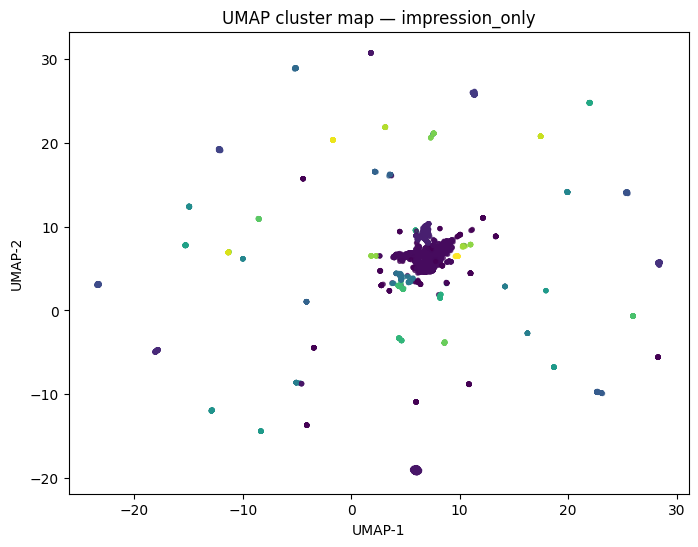

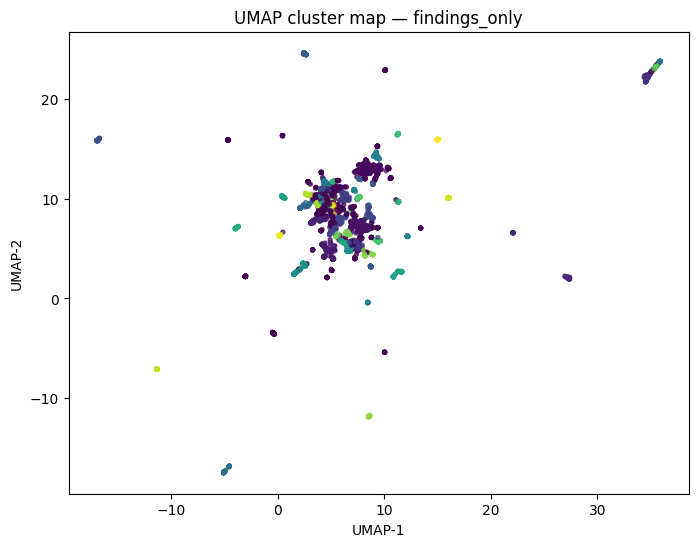

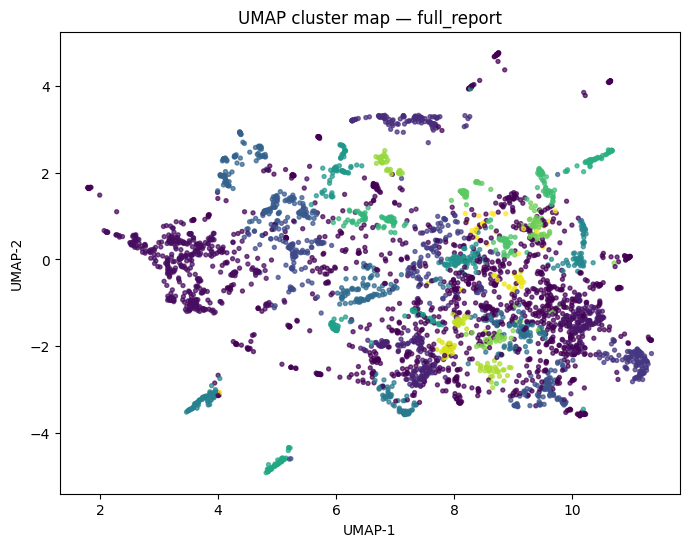

In [62]:
# Plot the clusters for each section variant
for variant_name, vdf in variant_dfs.items():
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        vdf["umap_x"],
        vdf["umap_y"],
        c=vdf["topic"],
        s=8,
        alpha=0.7
    )
    plt.title(f"UMAP cluster map — {variant_name}")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.show()

In [65]:
# Save document-level outputs and comparison table
output_dir = DATA_DIR / "embedding_clustering_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

comparison_df.to_csv(output_dir / "section_ablation_comparison.csv", index=False)

for variant_name, vdf in variant_dfs.items():
    vdf.to_csv(output_dir / f"{variant_name}_document_topics.csv", index=False)

    info = results[variant_name]["topic_model"].get_topic_info()
    info.to_csv(output_dir / f"{variant_name}_topic_info.csv", index=False)

print("Saved outputs to:", output_dir)
print(sorted([p.name for p in output_dir.iterdir()]))

Saved outputs to: /content/drive/MyDrive/AIHC 5010/Project 2/ecgen-radiology/embedding_clustering_outputs
['findings_only_document_topics.csv', 'findings_only_topic_info.csv', 'full_report_document_topics.csv', 'full_report_topic_info.csv', 'impression_only_document_topics.csv', 'impression_only_topic_info.csv', 'section_ablation_comparison.csv']


In [67]:
# inspect representative reports within each topic
def show_example_reports(vdf, topic_id, n=5):
    cols = ["report_id", "topic", "n_words", "max_topic_prob", "text"]
    out = vdf[vdf["topic"] == topic_id].sort_values(
        by="max_topic_prob", ascending=False
    )[cols].head(n)
    return out

display(show_example_reports(variant_dfs["impression_only"], topic_id=0, n=5))
display(show_example_reports(variant_dfs["findings_only"], topic_id=1, n=5))
display(show_example_reports(variant_dfs["full_report"], topic_id=2, n=5))

,report_id,topic,n_words,max_topic_prob,text
3915,CXR3994,0,7,1.0,Mild cardiomegaly with DEID_TOKEN of early fai...
3857,CXR3935,0,34,1.0,1. Blunting of the right costophrenic DEID_TOK...
3845,CXR3923,0,17,1.0,"Comparison DEID_TOKEN, DEID_TOKEN Well-expande..."
3837,CXR3915,0,7,1.0,Stable cardiomegaly. No acute infiltrate or ef...
3835,CXR3913,0,19,1.0,"Comparison DEID_TOKEN, DEID_TOKEN. Well-expand..."


,report_id,topic,n_words,max_topic_prob,text
16,CXR19,1,32,1.0,Heart size is normal. There is tortuosity of t...
72,CXR86,1,15,1.0,Heart size is within normal limits. No focal a...
159,CXR187,1,18,1.0,Normal heart size. Stable tortuous aorta. No p...
1100,CXR1269,1,22,1.0,Normal heart size. Hyperexpanded lungs without...
200,CXR236,1,15,1.0,Heart size is within normal limits. No focal a...


,report_id,topic,n_words,max_topic_prob,text
220,CXR225,2,31,1.0,"DEID_TOKEN-year-old male with DEID_TOKEN, shor..."
764,CXR777,2,49,1.0,DEID_TOKEN-year-old male with productive DEID_...
678,CXR691,2,34,1.0,DEID_TOKEN-year-old female with dyspnea.\nThe ...
424,CXR432,2,45,1.0,"DEID_TOKEN-year-old female, DEID_TOKEN, nonsmo..."
328,CXR336,2,36,1.0,DEID_TOKEN-year-old female with nightsweats an...


In [69]:
# Section ablation summary
def quick_ablation_readout(comparison_df):
    df = comparison_df.copy()

    print("Section ablation summary")
    print("-" * 80)

    for _, row in df.iterrows():
        print(
            f"{row['variant']}: "
            f"{int(row['n_docs'])} docs | "
            f"{int(row['n_clusters_excluding_noise'])} clusters | "
            f"{row['noise_pct']}% noise | "
            f"largest cluster {row['largest_cluster_pct']}% | "
            f"silhouette={row['silhouette_umap_non_noise']}"
        )

quick_ablation_readout(comparison_df)

Section ablation summary
--------------------------------------------------------------------------------
findings_only: 3425 docs | 45 clusters | 20.29% noise | largest cluster 7.62% | silhouette=0.5744
full_report: 3927 docs | 32 clusters | 31.17% noise | largest cluster 11.13% | silhouette=0.4442
impression_only: 3921 docs | 35 clusters | 8.08% noise | largest cluster 29.05% | silhouette=0.4861


2. Evaluate cluster quality using internal unsupervised metrics to determine which section yields the most coherent latent structure.

In [70]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

In [71]:
# Cluster quality metric helpers
def evaluate_cluster_quality(embeddings, embedding_2d, topics):
    """
    Internal unsupervised cluster-quality metrics.
    Noise points (-1) are excluded from geometry-based metrics.
    """
    topics = np.array(topics)

    non_noise_mask = topics != -1
    non_noise_topics = topics[non_noise_mask]

    results = {
        "n_docs_total": len(topics),
        "n_noise": int((topics == -1).sum()),
        "noise_pct": round(100 * np.mean(topics == -1), 2),
        "n_clusters_excluding_noise": int(len(np.unique(non_noise_topics))) if len(non_noise_topics) > 0 else 0
    }

    if len(non_noise_topics) < 10 or len(np.unique(non_noise_topics)) < 2:
        results.update({
            "silhouette_embedding": np.nan,
            "silhouette_umap2d": np.nan,
            "davies_bouldin_embedding": np.nan,
            "calinski_harabasz_embedding": np.nan,
            "largest_cluster_pct_non_noise": np.nan,
            "cluster_size_entropy_norm": np.nan
        })
        return results

    X_embed = embeddings[non_noise_mask]
    X_umap = embedding_2d[non_noise_mask]
    y = non_noise_topics

    # Geometry-based internal metrics
    try:
        results["silhouette_embedding"] = round(float(silhouette_score(X_embed, y, metric="cosine")), 4)
    except Exception:
        results["silhouette_embedding"] = np.nan

    try:
        results["silhouette_umap2d"] = round(float(silhouette_score(X_umap, y)), 4)
    except Exception:
        results["silhouette_umap2d"] = np.nan

    try:
        results["davies_bouldin_embedding"] = round(float(davies_bouldin_score(X_embed, y)), 4)
    except Exception:
        results["davies_bouldin_embedding"] = np.nan

    try:
        results["calinski_harabasz_embedding"] = round(float(calinski_harabasz_score(X_embed, y)), 4)
    except Exception:
        results["calinski_harabasz_embedding"] = np.nan

    # Cluster size concentration / balance
    cluster_sizes = pd.Series(y).value_counts().sort_values(ascending=False)
    probs = cluster_sizes.values / cluster_sizes.values.sum()

    results["largest_cluster_pct_non_noise"] = round(float(100 * probs[0]), 2)

    # normalized entropy of cluster sizes: higher = more balanced
    if len(probs) > 1:
        entropy = -np.sum(probs * np.log(probs + 1e-12))
        max_entropy = np.log(len(probs))
        results["cluster_size_entropy_norm"] = round(float(entropy / max_entropy), 4)
    else:
        results["cluster_size_entropy_norm"] = np.nan

    return results

In [72]:
# prototype-report helpers
def get_cluster_centroids(embeddings, topics):
    """
    Compute centroid for each non-noise cluster in embedding space.
    """
    topics = np.array(topics)
    centroids = {}

    for t in sorted(set(topics)):
        if t == -1:
            continue
        idx = np.where(topics == t)[0]
        cluster_emb = embeddings[idx]
        centroid = cluster_emb.mean(axis=0)
        centroids[t] = centroid

    return centroids


def get_prototype_indices(embeddings, topics, top_n=5):
    """
    For each cluster, return indices of the most central documents
    based on cosine similarity to the cluster centroid.
    """
    topics = np.array(topics)
    centroids = get_cluster_centroids(embeddings, topics)

    prototype_idx = {}

    for t, centroid in centroids.items():
        idx = np.where(topics == t)[0]
        cluster_emb = embeddings[idx]

        sims = cosine_similarity(cluster_emb, centroid.reshape(1, -1)).ravel()
        ranked_local = np.argsort(-sims)[:top_n]
        ranked_global = idx[ranked_local]

        prototype_idx[t] = {
            "indices": ranked_global.tolist(),
            "similarities": sims[ranked_local].tolist()
        }

    return prototype_idx

In [73]:
# keyword extraction helper

def extract_topic_keywords(topic_model, topic_id, top_n_words=10):
    words = topic_model.get_topic(topic_id)
    if words is None:
        return []
    return [w for w, score in words[:top_n_words]]

In [74]:
# Build a cluster summary table for one variant
def build_cluster_summary_table(
    variant_df,
    topic_model,
    embeddings,
    topics,
    probs=None,
    top_n_keywords=10,
    top_n_prototypes=3
):
    """
    Produce one row per cluster with:
    - cluster size
    - keywords
    - representative prototype reports
    """
    df = variant_df.copy().reset_index(drop=True)
    df["topic"] = topics

    if probs is not None and isinstance(probs, np.ndarray) and probs.ndim == 2:
        df["max_topic_prob"] = probs.max(axis=1)
    else:
        df["max_topic_prob"] = np.nan

    prototype_idx = get_prototype_indices(embeddings, topics, top_n=top_n_prototypes)

    rows = []

    non_noise_topics = sorted([t for t in set(topics) if t != -1])

    for t in non_noise_topics:
        topic_docs = df[df["topic"] == t].copy()
        topic_docs = topic_docs.sort_values("max_topic_prob", ascending=False)

        keywords = extract_topic_keywords(topic_model, t, top_n_words=top_n_keywords)

        proto_info = prototype_idx.get(t, {"indices": [], "similarities": []})
        proto_indices = proto_info["indices"]
        proto_sims = proto_info["similarities"]

        prototype_texts = []
        prototype_ids = []

        for j, idx in enumerate(proto_indices):
            row = df.iloc[idx]
            prototype_ids.append(row["report_id"])

            text_clean = str(row["text"]).replace("\n", " ").strip()
            text_clean = re.sub(r"\s+", " ", text_clean)

            # truncate for readability
            snippet = text_clean[:350] + ("..." if len(text_clean) > 350 else "")
            sim_val = proto_sims[j] if j < len(proto_sims) else np.nan

            prototype_texts.append(f"[report_id={row['report_id']}, cos_sim={sim_val:.4f}] {snippet}")

        rows.append({
            "topic": t,
            "cluster_size": int(len(topic_docs)),
            "keywords": ", ".join(keywords),
            "prototype_report_ids": "; ".join(map(str, prototype_ids)),
            "prototype_reports": "\n\n".join(prototype_texts)
        })

    summary_df = pd.DataFrame(rows).sort_values("cluster_size", ascending=False).reset_index(drop=True)
    return summary_df

In [75]:
# Evaluate all three section variants
quality_rows = []

for variant_name, vdf in variant_dfs.items():
    quality = evaluate_cluster_quality(
        embeddings=results[variant_name]["embeddings"],
        embedding_2d=results[variant_name]["embedding_2d"],
        topics=results[variant_name]["topics"]
    )
    quality["variant"] = variant_name
    quality_rows.append(quality)

quality_df = pd.DataFrame(quality_rows)[[
    "variant",
    "n_docs_total",
    "n_clusters_excluding_noise",
    "n_noise",
    "noise_pct",
    "silhouette_embedding",
    "silhouette_umap2d",
    "davies_bouldin_embedding",
    "calinski_harabasz_embedding",
    "largest_cluster_pct_non_noise",
    "cluster_size_entropy_norm"
]].sort_values("variant").reset_index(drop=True)

quality_df

,variant,n_docs_total,n_clusters_excluding_noise,n_noise,noise_pct,silhouette_embedding,silhouette_umap2d,davies_bouldin_embedding,calinski_harabasz_embedding,largest_cluster_pct_non_noise,cluster_size_entropy_norm
0,findings_only,3425,45,695,20.29,0.1481,0.5744,2.3544,56.7816,9.56,0.9588
1,full_report,3927,32,1224,31.17,0.0561,0.4442,2.9278,42.1719,16.17,0.9339
2,impression_only,3921,35,317,8.08,0.1745,0.4861,1.6690,108.7376,31.60,0.8091


In [76]:
# Rank the three section variants
def rank_variants(quality_df):
    df = quality_df.copy()

    # Higher is better
    rank_high = [
        "silhouette_embedding",
        "silhouette_umap2d",
        "calinski_harabasz_embedding",
        "cluster_size_entropy_norm"
    ]

    # Lower is better
    rank_low = [
        "davies_bouldin_embedding",
        "noise_pct",
        "largest_cluster_pct_non_noise"
    ]

    for col in rank_high:
        df[f"rank_{col}"] = df[col].rank(ascending=False, method="min")

    for col in rank_low:
        df[f"rank_{col}"] = df[col].rank(ascending=True, method="min")

    rank_cols = [c for c in df.columns if c.startswith("rank_")]
    df["mean_rank"] = df[rank_cols].mean(axis=1)

    return df.sort_values("mean_rank").reset_index(drop=True)

quality_ranked_df = rank_variants(quality_df)
quality_ranked_df

,variant,n_docs_total,n_clusters_excluding_noise,n_noise,noise_pct,silhouette_embedding,silhouette_umap2d,davies_bouldin_embedding,calinski_harabasz_embedding,largest_cluster_pct_non_noise,cluster_size_entropy_norm,rank_silhouette_embedding,rank_silhouette_umap2d,rank_calinski_harabasz_embedding,rank_cluster_size_entropy_norm,rank_davies_bouldin_embedding,rank_noise_pct,rank_largest_cluster_pct_non_noise,mean_rank
0,findings_only,3425,45,695,20.29,0.1481,0.5744,2.3544,56.7816,9.56,0.9588,2.0,1.0,2.0,1.0,2.0,2.0,1.0,1.571429
1,impression_only,3921,35,317,8.08,0.1745,0.4861,1.6690,108.7376,31.60,0.8091,1.0,2.0,1.0,3.0,1.0,1.0,3.0,1.714286
2,full_report,3927,32,1224,31.17,0.0561,0.4442,2.9278,42.1719,16.17,0.9339,3.0,3.0,3.0,2.0,3.0,3.0,2.0,2.714286


3. Generate cluster summaries using characteristic keywords and representative prototype reports for each cluster.

In [77]:
# Generate cluster summaries for all three variants
cluster_summary_tables = {}

for variant_name, vdf in variant_dfs.items():
    summary_df = build_cluster_summary_table(
        variant_df=vdf,
        topic_model=results[variant_name]["topic_model"],
        embeddings=results[variant_name]["embeddings"],
        topics=results[variant_name]["topics"],
        probs=results[variant_name]["probs"],
        top_n_keywords=10,
        top_n_prototypes=3
    )

    cluster_summary_tables[variant_name] = summary_df

    print("\n" + "=" * 100)
    print(f"CLUSTER SUMMARIES: {variant_name}")
    print("=" * 100)
    display(summary_df.head(10))


CLUSTER SUMMARIES: impression_only


,topic,cluster_size,keywords,prototype_report_ids,prototype_reports
0,0,1139,"deidtoken, right, left, atelectasis, cardiomeg...",CXR3968; CXR385; CXR981,"[report_id=CXR3968, cos_sim=0.8386] Left lower..."
1,1,286,"abnormality acute, cardiopulmonary abnormality...",CXR3977; CXR2491; CXR2622,"[report_id=CXR3977, cos_sim=0.9987] No acute c..."
2,2,247,"heart size, size, heart, normal, lungs clear, ...",CXR3008; CXR2712; CXR2436,"[report_id=CXR3008, cos_sim=0.9357] Heart size..."
3,3,134,"active disease, active, disease, change, disea...",CXR43; CXR100; CXR134,"[report_id=CXR43, cos_sim=1.0000] No active di..."
4,4,128,"abnormalities acute, cardiopulmonary abnormali...",CXR89; CXR94; CXR114,"[report_id=CXR89, cos_sim=0.9999] No acute car..."
5,5,122,"cardiopulmonary disease, disease acute, diseas...",CXR3937; CXR3947; CXR8,"[report_id=CXR3937, cos_sim=0.9996] No acute c..."
6,6,114,"acute disease, disease acute, disease, acute, ...",CXR32; CXR37; CXR56,"[report_id=CXR32, cos_sim=1.0000] No acute dis..."
7,7,113,"cardiopulmonary findings, findings acute, find...",CXR6; CXR11; CXR15,"[report_id=CXR6, cos_sim=1.0000] No acute card..."
8,8,97,"abnormality acute, cardiopulmonary abnormality...",CXR36; CXR248; CXR261,"[report_id=CXR36, cos_sim=0.9999] No acute car..."
9,9,83,"process acute, cardiopulmonary process, proces...",CXR3837; CXR3948; CXR10,"[report_id=CXR3837, cos_sim=0.9994] No acute c..."



CLUSTER SUMMARIES: findings_only


,topic,cluster_size,keywords,prototype_report_ids,prototype_reports
0,0,261,"cardiomediastinal, cardiomediastinal silhouett...",CXR560; CXR3576; CXR247,"[report_id=CXR560, cos_sim=0.9419] The cardiom..."
1,1,195,"size normal, heart size, size, disease, airspa...",CXR652; CXR3933; CXR3206,"[report_id=CXR652, cos_sim=0.9463] Heart size ..."
2,2,112,"clear focal, pneumothoraces heart, pneumothora...",CXR986; CXR2964; CXR3208,"[report_id=CXR986, cos_sim=0.9472] The lungs a..."
3,3,97,"alveolar consolidation, alveolar, definite, en...",CXR906; CXR722; CXR3590,"[report_id=CXR906, cos_sim=0.9445] Heart size ..."
4,4,86,"structures thorax, silhouette unremarkable, ac...",CXR36; CXR107; CXR291,"[report_id=CXR36, cos_sim=0.9960] The lungs ar..."
5,5,83,"size mediastinum, heart normal, mediastinum, n...",CXR1894; CXR2685; CXR1196,"[report_id=CXR1894, cos_sim=0.9575] The heart ..."
6,6,78,"size mediastinal, mediastinal contours, airspa...",CXR2029; CXR2937; CXR3265,"[report_id=CXR2029, cos_sim=0.9603] Normal hea..."
7,7,76,"cardiomegaly, mild cardiomegaly, mild, consoli...",CXR3994; CXR2506; CXR1857,"[report_id=CXR3994, cos_sim=0.8869] Similar mi..."
8,8,72,"low, volumes, lung volumes, low lung, lung, si...",CXR2235; CXR1706; CXR3896,"[report_id=CXR2235, cos_sim=0.9129] There are ..."
9,9,69,"airspace opacity, opacity pleural, opacity, ca...",CXR1802; CXR1330; CXR3012,"[report_id=CXR1802, cos_sim=0.9656] The heart ..."



CLUSTER SUMMARIES: full_report


,topic,cluster_size,keywords,prototype_report_ids,prototype_reports
0,0,437,"pain, chest pain, chest, normal, acute, lungs,...",CXR3832; CXR2517; CXR2354,"[report_id=CXR3832, cos_sim=0.9280] Chest pain..."
1,1,156,"deidtokenyearold, female, deidtokenyearold fem...",CXR2264; CXR3431; CXR3089,"[report_id=CXR2264, cos_sim=0.9636] DEID_TOKEN..."
2,2,134,"cardiomediastinal, cardiomediastinal silhouett...",CXR725; CXR809; CXR3361,"[report_id=CXR725, cos_sim=0.9673] DEID_TOKEN-..."
3,3,128,"size mediastinum, acute disease, heart normal,...",CXR1368; CXR1259; CXR3181,"[report_id=CXR1368, cos_sim=0.9539] DEID_TOKEN..."
4,4,118,"pulmonary edema, edema, typical, alveolar cons...",CXR1715; CXR2632; CXR3552,"[report_id=CXR1715, cos_sim=0.9618] DEID_TOKEN..."
5,5,104,"deidtoken, calcified, lobe, left, right, nodul...",CXR48; CXR1250; CXR3725,"[report_id=CXR48, cos_sim=0.9347] DEID_TOKEN-y..."
6,6,103,"breath, shortness breath, shortness, normal, p...",CXR1192; CXR2068; CXR2316,"[report_id=CXR1192, cos_sim=0.9108] Shortness ..."
7,7,103,"pain, chest pain, deidtokenyearold, chest, car...",CXR3433; CXR2835; CXR888,"[report_id=CXR3433, cos_sim=0.9619] DEID_TOKEN..."
8,8,100,"size normal, clear, dyspnea, heart, heart size...",CXR2712; CXR2436; CXR1369,"[report_id=CXR2712, cos_sim=0.9317] dyspnea. H..."
9,9,98,"contours normal, cardiac, preop, contours, car...",CXR1928; CXR1738; CXR2700,"[report_id=CXR1928, cos_sim=0.9086] DEID_TOKEN..."


In [79]:
# Display full details for one cluster
def inspect_cluster(variant_name, topic_id, n_extra_examples=5):
    vdf = variant_dfs[variant_name].copy().reset_index(drop=True)
    vdf["topic"] = results[variant_name]["topics"]

    probs = results[variant_name]["probs"]
    if isinstance(probs, np.ndarray) and probs.ndim == 2:
        vdf["max_topic_prob"] = probs.max(axis=1)
    else:
        vdf["max_topic_prob"] = np.nan

    topic_model = results[variant_name]["topic_model"]
    keywords = extract_topic_keywords(topic_model, topic_id, top_n_words=12)

    print(f"Variant: {variant_name}")
    print(f"Topic: {topic_id}")
    print(f"Keywords: {', '.join(keywords)}")
    print("-" * 80)

    subset = vdf[vdf["topic"] == topic_id].sort_values("max_topic_prob", ascending=False).head(n_extra_examples)

    for _, row in subset.iterrows():
        text_clean = str(row["text"]).replace("\n", " ").strip()
        text_clean = re.sub(r"\s+", " ", text_clean)
        snippet = text_clean[:500] + ("..." if len(text_clean) > 500 else "")

        print(f"report_id={row['report_id']} | max_topic_prob={row['max_topic_prob']}")
        print(snippet)
        print("-" * 80)

# Example:
inspect_cluster("full_report", topic_id=0, n_extra_examples=5)

Variant: full_report
Topic: 0
Keywords: pain, chest pain, chest, normal, acute, lungs, pleural, pulmonary, clear, size
--------------------------------------------------------------------------------
report_id=CXR3967 | max_topic_prob=1.0
Chest pain The cardiomediastinal silhouette is within normal limits for size and contour. The lungs are normally inflated without evidence of focal airspace disease, pleural effusion, or pneumothorax. Mild degenerative endplate changes of the spine. 1. No acute radiographic cardiopulmonary process.
--------------------------------------------------------------------------------
report_id=CXR3832 | max_topic_prob=1.0
Chest pain The lungs are clear. There is no pleural effusion or pneumothorax. The heart is not enlarged. There are calcified mediastinal lymph DEID_TOKEN. The skeletal structures are normal. No acute pulmonary disease.
--------------------------------------------------------------------------------
report_id=CXR349 | max_topic_prob=1.0
che

In [80]:
# Save the quality table and cluster summaries
quality_df.to_csv(output_dir / "cluster_quality_metrics.csv", index=False)
quality_ranked_df.to_csv(output_dir / "cluster_quality_ranked.csv", index=False)

for variant_name, summary_df in cluster_summary_tables.items():
    summary_df.to_csv(output_dir / f"{variant_name}_cluster_summaries.csv", index=False)

print("Saved:")
print(output_dir / "cluster_quality_metrics.csv")
print(output_dir / "cluster_quality_ranked.csv")
for variant_name in cluster_summary_tables:
    print(output_dir / f"{variant_name}_cluster_summaries.csv")

Saved:
/content/drive/MyDrive/AIHC 5010/Project 2/ecgen-radiology/embedding_clustering_outputs/cluster_quality_metrics.csv
/content/drive/MyDrive/AIHC 5010/Project 2/ecgen-radiology/embedding_clustering_outputs/cluster_quality_ranked.csv
/content/drive/MyDrive/AIHC 5010/Project 2/ecgen-radiology/embedding_clustering_outputs/impression_only_cluster_summaries.csv
/content/drive/MyDrive/AIHC 5010/Project 2/ecgen-radiology/embedding_clustering_outputs/findings_only_cluster_summaries.csv
/content/drive/MyDrive/AIHC 5010/Project 2/ecgen-radiology/embedding_clustering_outputs/full_report_cluster_summaries.csv


In [81]:
def print_quality_interpretation(quality_ranked_df):
    best = quality_ranked_df.iloc[0]

    print("Internal cluster-quality summary")
    print("=" * 80)
    print(f"Best-performing section variant: {best['variant']}")
    print(f"- Number of clusters: {best['n_clusters_excluding_noise']}")
    print(f"- Noise rate: {best['noise_pct']}%")
    print(f"- Silhouette (embedding): {best['silhouette_embedding']}")
    print(f"- Silhouette (UMAP 2D): {best['silhouette_umap2d']}")
    print(f"- Davies–Bouldin: {best['davies_bouldin_embedding']}")
    print(f"- Calinski–Harabasz: {best['calinski_harabasz_embedding']}")
    print(f"- Largest cluster share: {best['largest_cluster_pct_non_noise']}%")
    print(f"- Cluster size entropy: {best['cluster_size_entropy_norm']}")
    print()
    print("Interpretation guide:")
    print("- Higher silhouette is better.")
    print("- Lower Davies–Bouldin is better.")
    print("- Higher Calinski–Harabasz is better.")
    print("- Lower noise is usually better.")
    print("- Lower largest-cluster share and higher entropy suggest less collapse into one broad cluster.")

print_quality_interpretation(quality_ranked_df)

Internal cluster-quality summary
Best-performing section variant: findings_only
- Number of clusters: 45
- Noise rate: 20.29%
- Silhouette (embedding): 0.1481
- Silhouette (UMAP 2D): 0.5744
- Davies–Bouldin: 2.3544
- Calinski–Harabasz: 56.7816
- Largest cluster share: 9.56%
- Cluster size entropy: 0.9588

Interpretation guide:
- Higher silhouette is better.
- Lower Davies–Bouldin is better.
- Higher Calinski–Harabasz is better.
- Lower noise is usually better.
- Lower largest-cluster share and higher entropy suggest less collapse into one broad cluster.


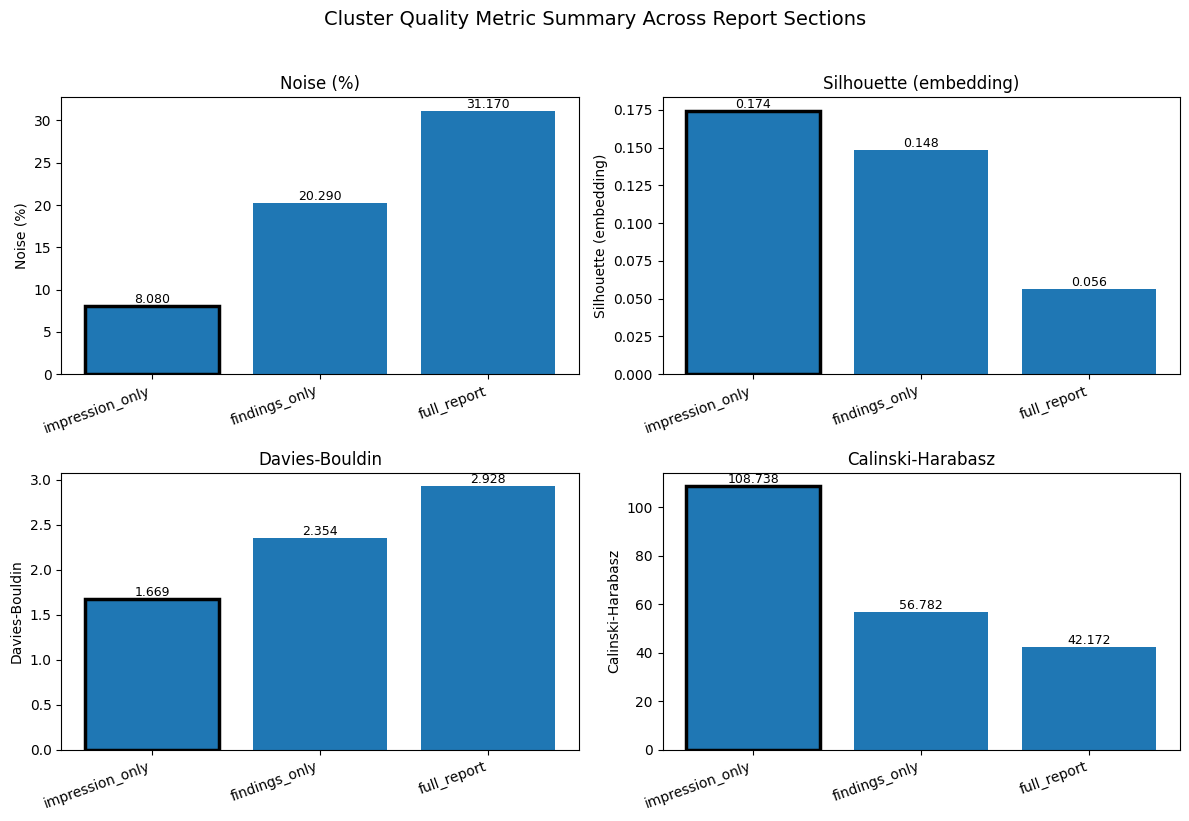

In [82]:
# =========================
# Metric summary plot
# =========================

import matplotlib.pyplot as plt
import numpy as np

# Make a copy so we don't modify the original table
plot_df = quality_df.copy()

# Optional: set display order
variant_order = ["impression_only", "findings_only", "full_report"]
plot_df["variant"] = pd.Categorical(plot_df["variant"], categories=variant_order, ordered=True)
plot_df = plot_df.sort_values("variant").reset_index(drop=True)

# Metrics to plot
metrics = [
    ("noise_pct", "Noise (%)", False),                        # lower is better
    ("silhouette_embedding", "Silhouette (embedding)", True),# higher is better
    ("davies_bouldin_embedding", "Davies-Bouldin", False),   # lower is better
    ("calinski_harabasz_embedding", "Calinski-Harabasz", True) # higher is better
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

x = np.arange(len(plot_df))
labels = plot_df["variant"].astype(str).tolist()

for ax, (col, title, higher_better) in zip(axes, metrics):
    values = plot_df[col].values

    bars = ax.bar(x, values)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_title(title)
    ax.set_ylabel(title)

    # Mark best bar
    valid_idx = np.where(~pd.isna(values))[0]
    if len(valid_idx) > 0:
        if higher_better:
            best_idx = valid_idx[np.argmax(values[valid_idx])]
        else:
            best_idx = valid_idx[np.argmin(values[valid_idx])]

        bars[best_idx].set_edgecolor("black")
        bars[best_idx].set_linewidth(2.5)

    # Add value labels
    for i, v in enumerate(values):
        if pd.notna(v):
            ax.text(i, v, f"{v:.3f}" if abs(v) < 1000 else f"{v:.1f}",
                    ha="center", va="bottom", fontsize=9)

plt.suptitle("Cluster Quality Metric Summary Across Report Sections", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()